# Introduction to Machine Learning
### A practical guide for ecologists, conservation biologists, and spatial scientists

---

> *"The greatest value of a picture is when it forces us to notice what we never expected to see."*
> — John W. Tukey

---

Every science has its revolutions. Ecology's quiet one is happening right now, and it is being driven by machine learning. In the last fifteen years, the way we identify birds from their calls, map forests from space, predict where a jaguar might roam, and decide which patch of savanna should become a protected area has been transformed by a handful of algorithms working on increasingly vast quantities of data. This section will introduce you to those algorithms, one notebook at a time, and by the end you will not only understand them, you will be using them to answer ecological questions that genuinely matter.

This first notebook is the start. We will not fit a model here, instead we will build a shared vocabulary, look at what machine learning actually *is*, and explore the fundamental ideas that will carry through the remaining notebooks under Machine Learning. Every concept is grounded in ecology.

#### What this notebook covers

1. What machine learning is, and how it differs from classical programming
2. The three core tasks: classification, regression, and clustering
3. Supervised versus unsupervised learning
4. The general machine-learning workflow
5. Why data matters more than algorithms
6. The fundamental tension between underfitting and overfitting
7. Ecological and conservation applications that are genuinely changing the field
8. A short hands-on preview with the Palmer penguins

#### R packages required

```r
install.packages(c("tidyverse", "patchwork", "showtext",
                   "ggridges", "palmerpenguins", "scales"))
```


---
## What is Machine Learning?

Every field has its origin story. Machine learning's story starts in 1959, when [Arthur Samuel](http://infolab.stanford.edu/pub/voy/museum/samuel.html) — an engineer at IBM — wrote a checkers-playing program that improved as it played. Samuel described this enterprise, in a phrase that has outlived his program by several technological revolutions, as *"the field of study that gives computers the ability to learn without being explicitly programmed"*. Nearly seventy years later, the essence of that definition still holds. Before Samuel, the dominant paradigm was *rule-based programming*: a human expert wrote a set of rules, the computer followed them faithfully, and any weakness in the rules became a weakness in the system. Samuel flipped the arrow. Instead of asking an expert to describe the rules, he asked the computer to **discover** them by watching thousands of games.

Think about how you, as an ecologist, are already learning to identify plants. Nobody has handed you a 200-page book for separating Proteaceae from Asphodelaceae. Instead, a mentor points at specimens, names them, draws your attention to subtle cues, and corrects you when you get one wrong. Over weeks and outings, your brain quietly constructs an internal model of what makes a Proteaceae plant *look* like a Proteaceae plant. That model generalises: when you see a Proteaceae plant you have never seen before, you recognise it.

Machine learning is the same process translated into silicon. We show a computer many examples, tell it what each one is (sometimes), and it learns a function that maps inputs to outputs. When a new, unseen observation arrives, the model applies what it has learned and produces an answer. The mentor's role is played by a **learning algorithm** that tweaks the model's internal parameters until its predictions start matching reality. Tom Mitchell, in his 1997 textbook, gave the idea a more careful definition: *a computer program is said to learn from experience E with respect to some task T and performance measure P, if its performance on T, as measured by P, improves with E*. In the Proteaceae example, T is naming the species, E is each labelled example you see, and P is the fraction of plants you get right next time. If P rises as E grows, learning is happening.

### The three questions machine learning answers

Almost every ecological problem that a machine-learning model can tackle boils down to one of three questions, each corresponding to a family of techniques you will meet later in other Machine Learning notebooks.

| Question | ML task | Ecological example |
|---|---|---|
| Which category does this observation belong to? | **Classification** | Is this Sentinel-2 pixel forest, water, or urban? |
| What value will this observation take? | **Regression** | How much above-ground biomass does this forest plot hold? |
| What natural groups live inside this dataset? | **Clustering** | What distinct vegetation communities exist along this gradient? |

The figure below shows the three tasks in their simplest visual form. Each panel tells a different story; together they frame everything that follows.

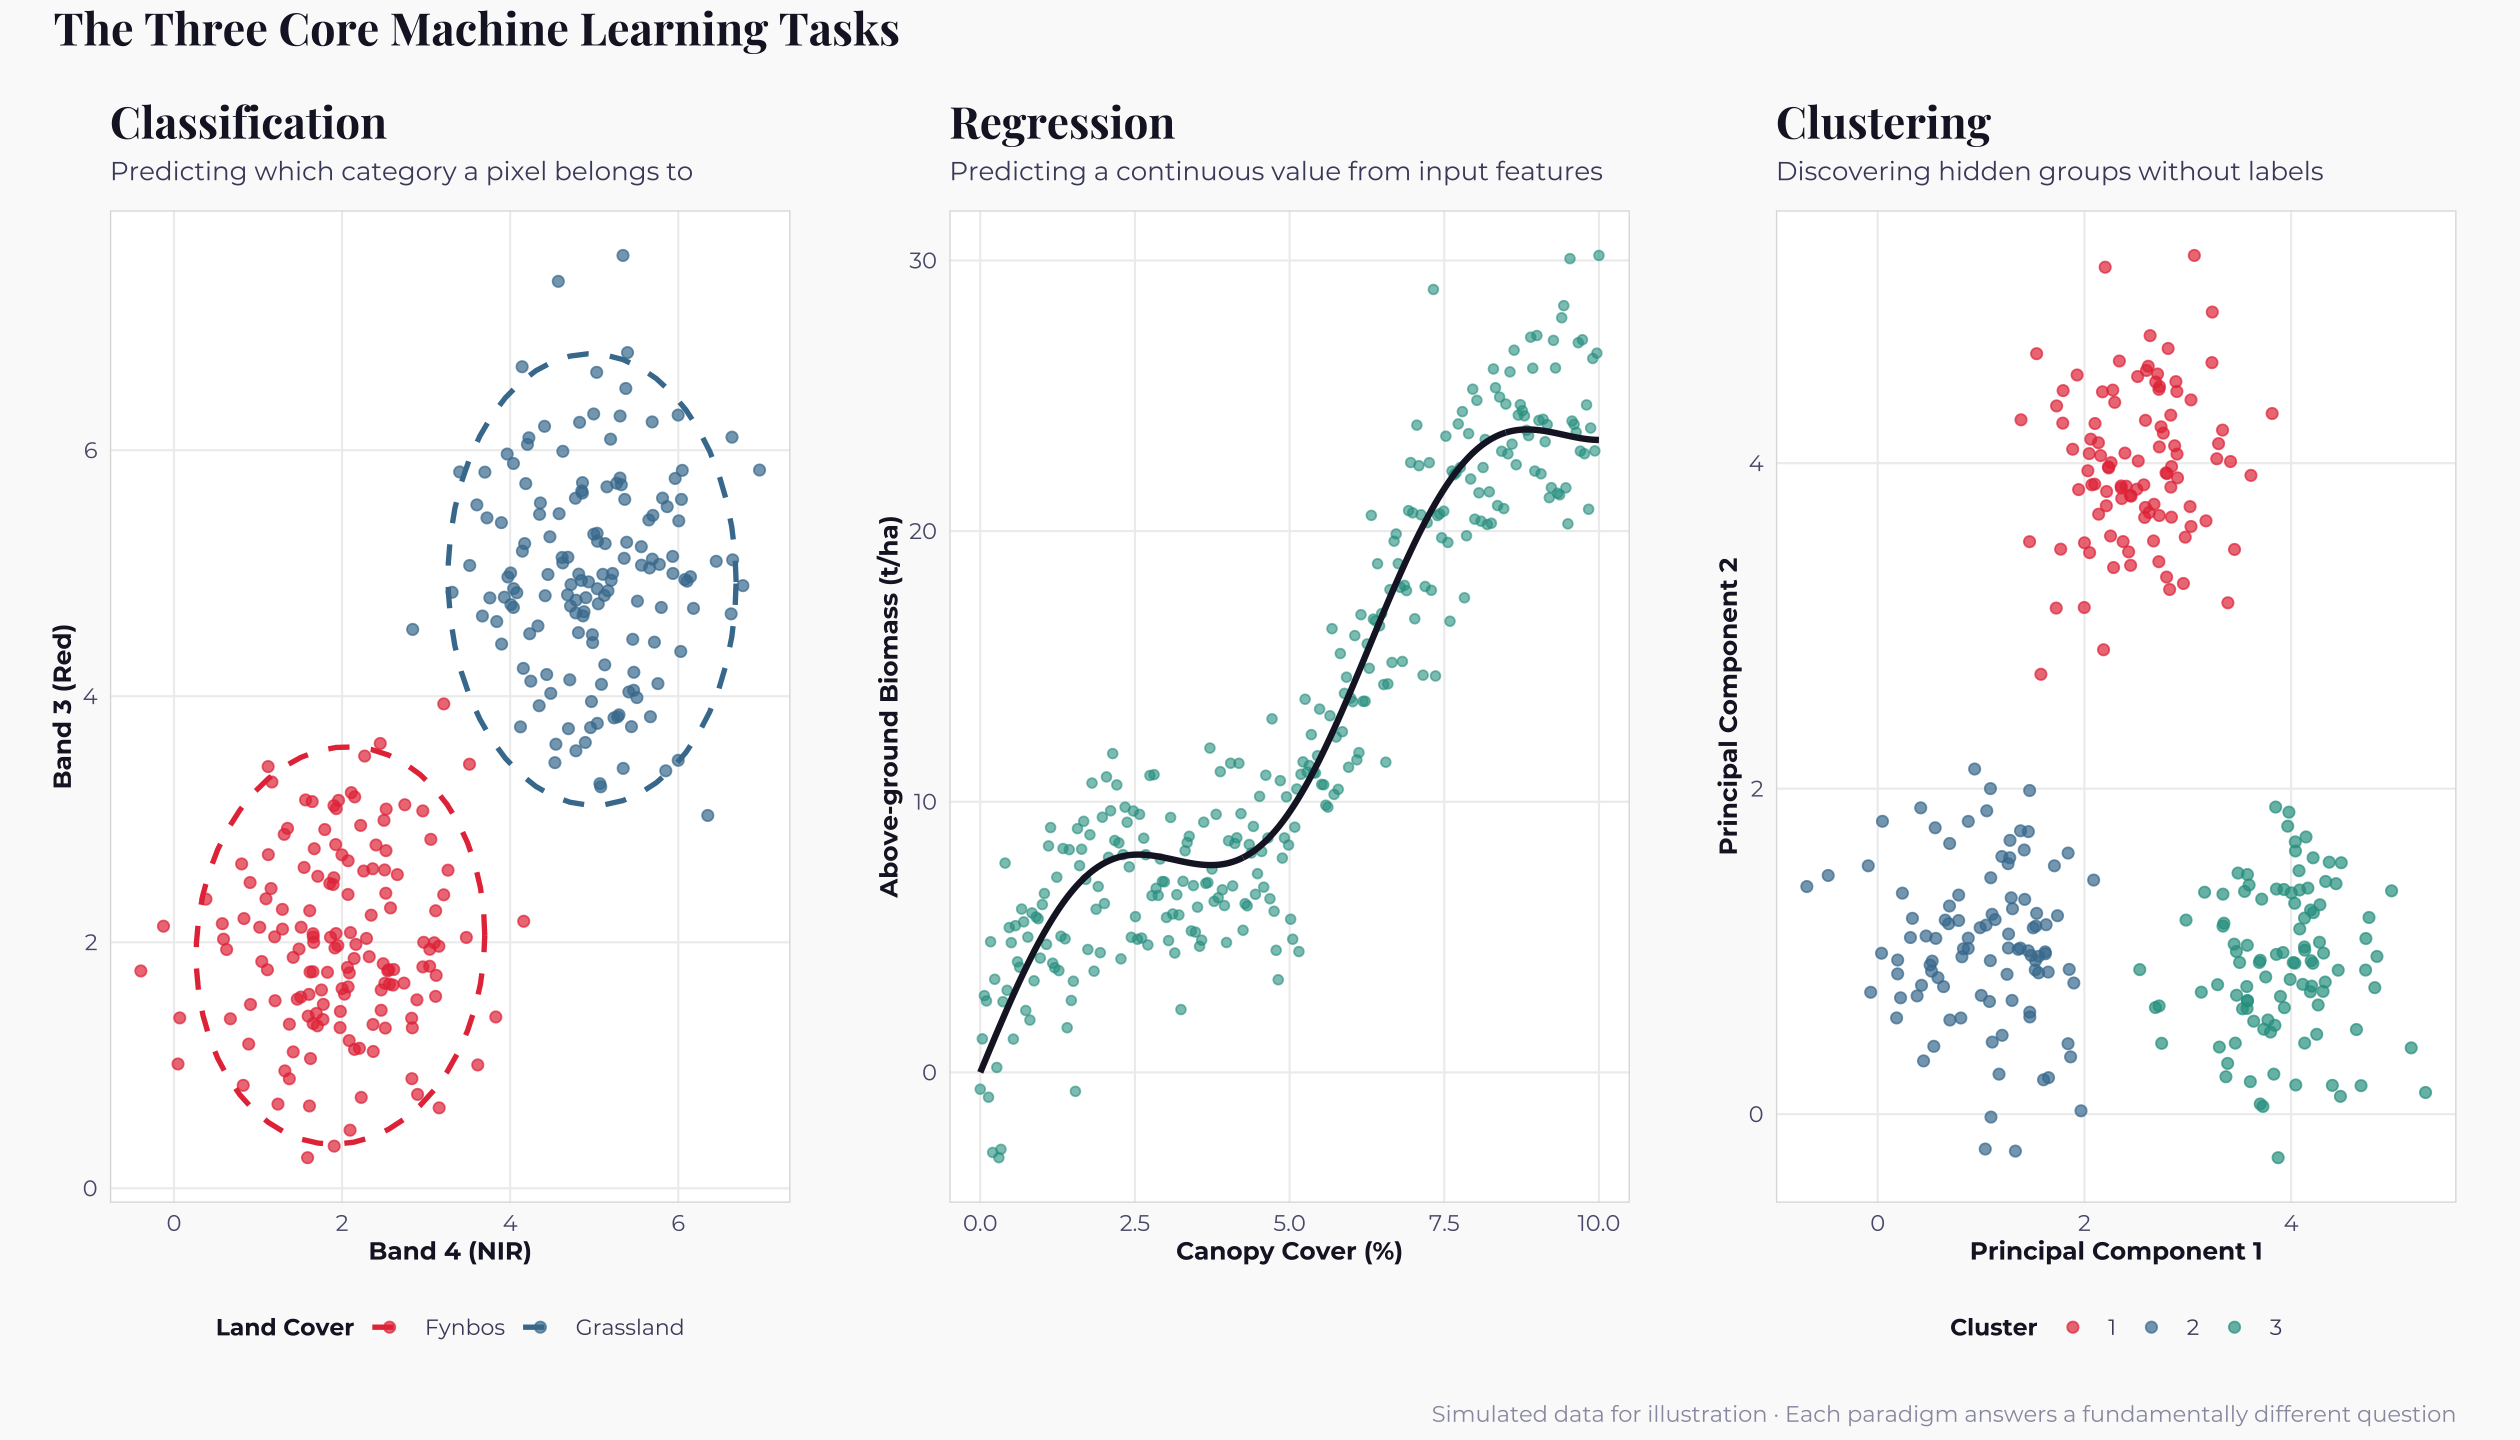

## Traditional programming, flipped upside-down

A useful way to understand what machine learning actually *does* is to place it beside traditional programming. In classical software engineering, a programmer writes a set of rules; the computer takes those rules, applies them to data, and produces answers. A biologist might write *"if wingspan is greater than sixty centimetres and the beak is hooked, then the bird is a raptor"*. The rule-writer is the expert; the computer is a faithful but uncreative clerk.

Machine learning reverses two of those boxes. We feed the computer **data and answers**, and it produces the **rules** — or rather a model that behaves as if rules had been written. The expertise no longer lives in someone's head; it is distilled from labelled examples. This is why we talk about a model having been *"trained"* rather than *"written"*, and it is why adding more data to a trained model often makes it smarter in a way that adding more lines of code to a traditional program almost never does.

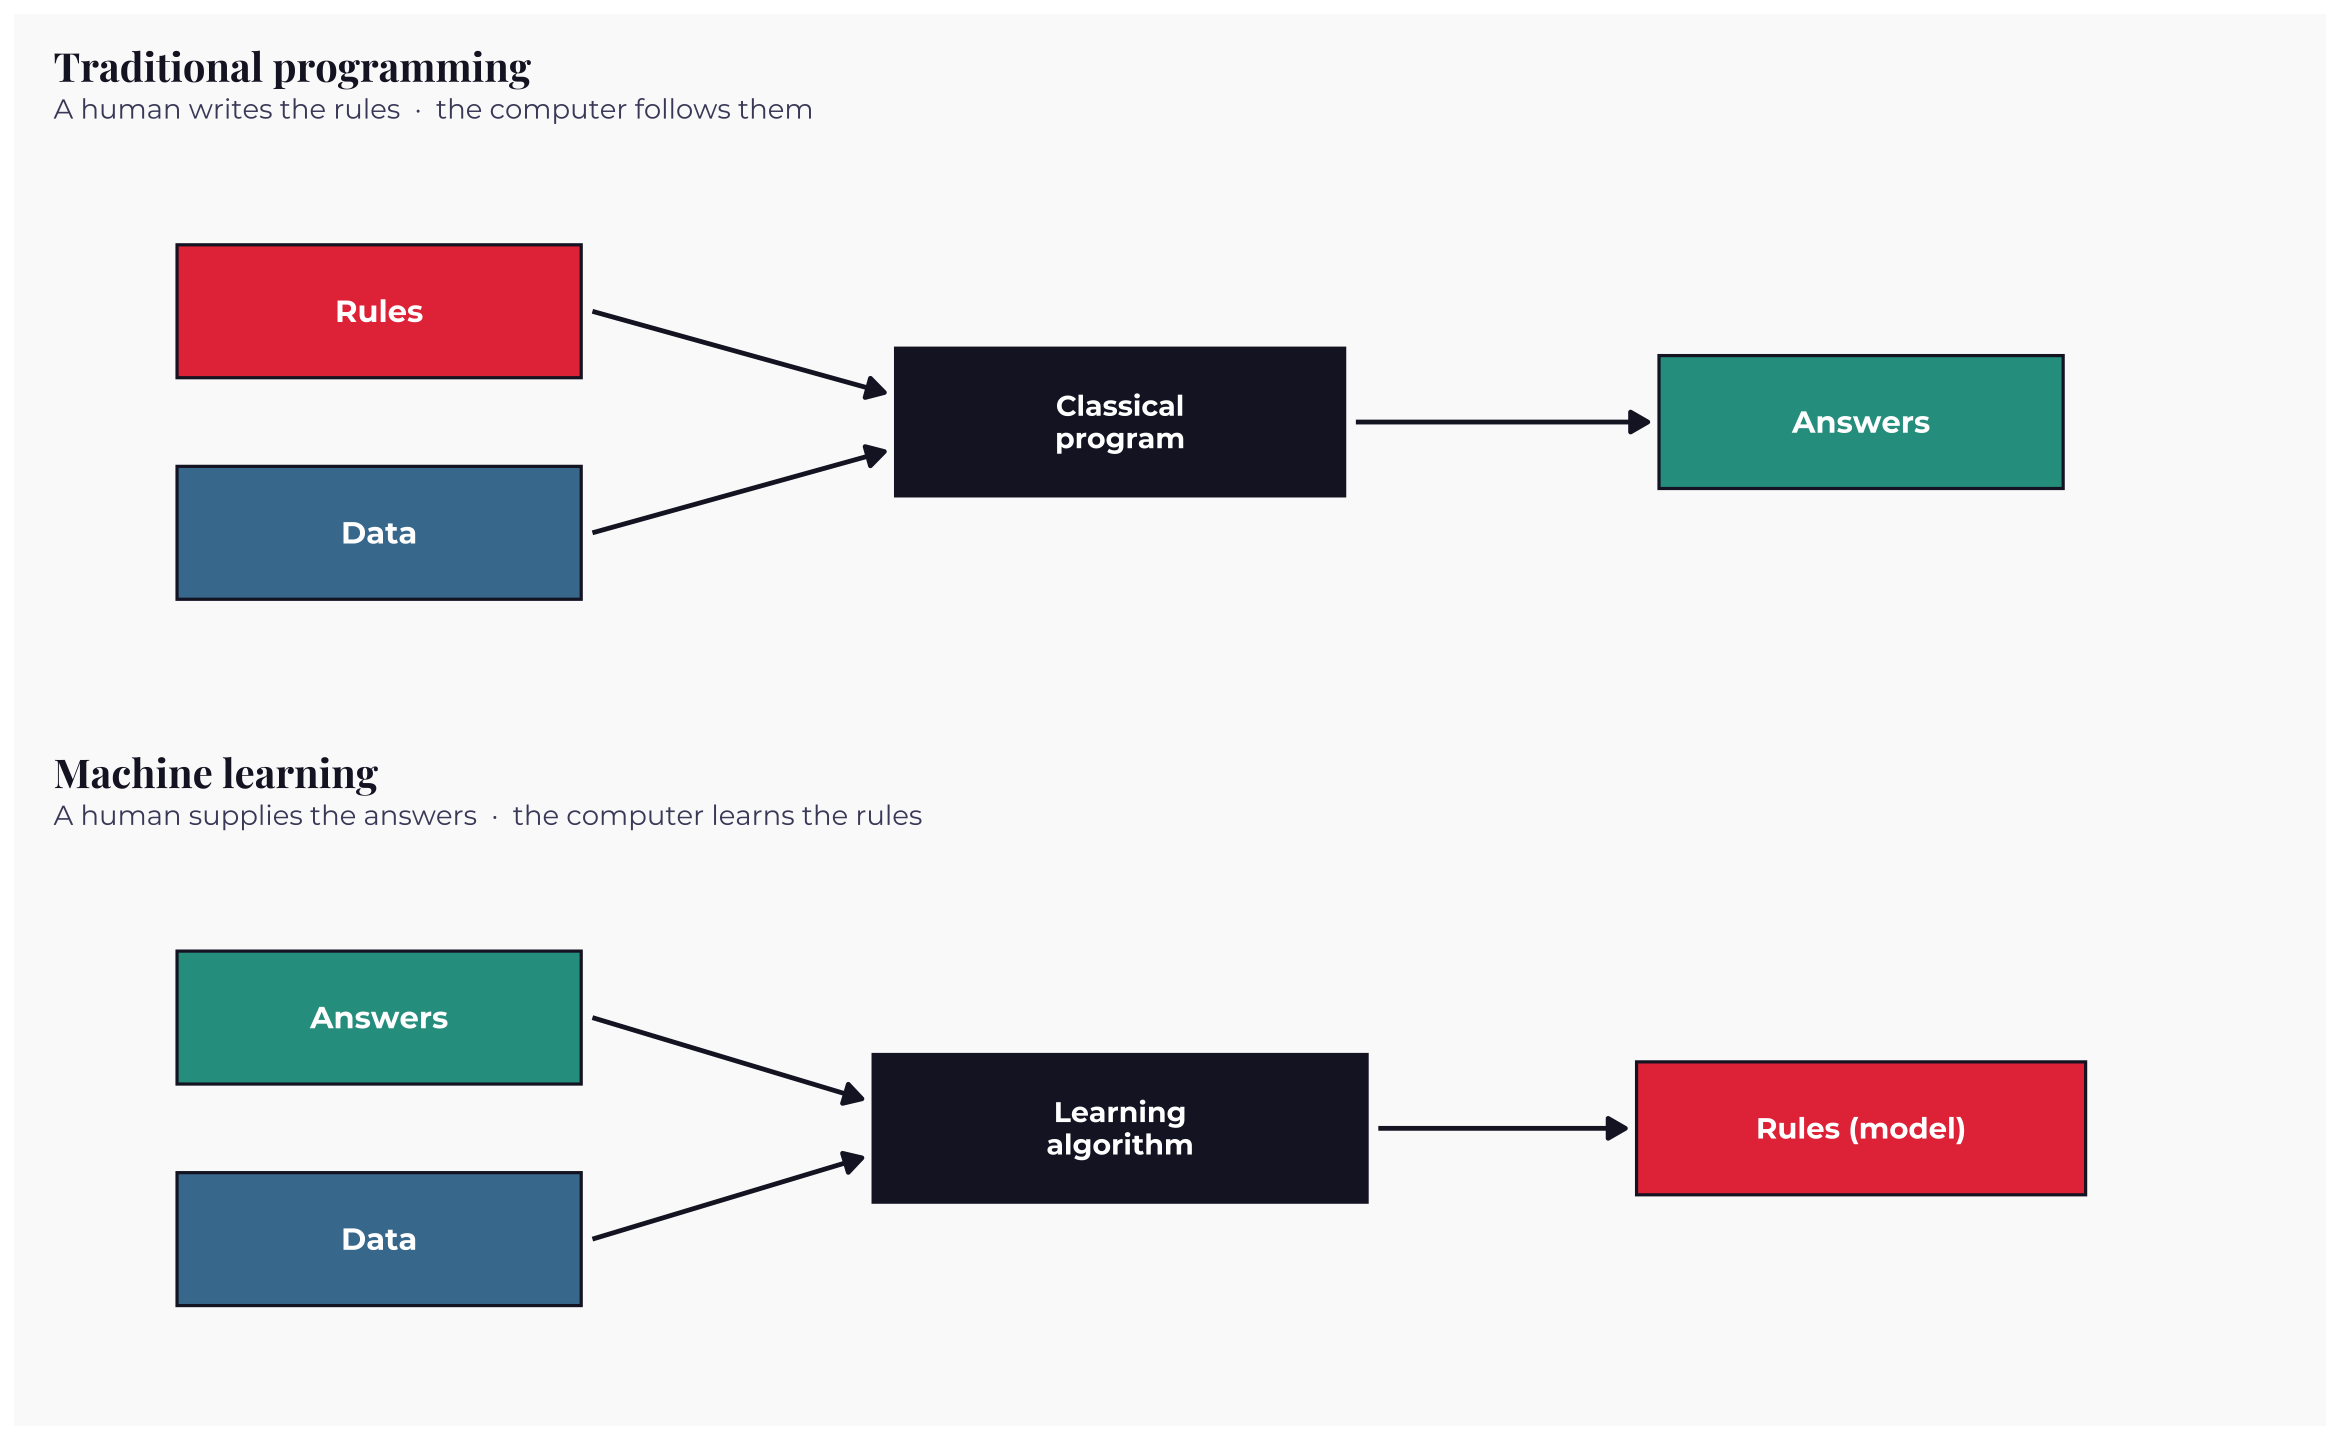

The ecological implications are profound. Rule-based approaches scale poorly: a single person can only describe so many rules, and every edge case needs a new clause. Machine-learning approaches scale with data availability. Tell a convolutional neural network the species of a thousand camera-trap images and it will learn features that no human would have thought to write down. Give it a million images and it will outperform almost any human expert on speed and consistency, though not always on judgement.

## Supervised and unsupervised learning

The most fundamental division in machine learning is whether your data have labels. If they do, you are working in the world of **supervised learning**; if they do not, you have stepped into **unsupervised learning**. The distinction matters because it determines which algorithms you can use, which questions you can ask, and how you evaluate whether your model is any good.

### Supervised learning — guided by ground truth

Supervised learning is what happens when you have both the inputs (often called **features** or **predictors**) and the correct outputs (called **labels** or **targets**). The learning algorithm's job is to find a function that maps inputs to outputs well enough to generalise to new, unseen observations. A supervised model is trained on a collection of examples for which the truth is known, and is then asked to predict the truth for examples it has never seen. This is the flavour of learning behind most of the ecological machine-learning victories of the last decade: land-cover maps are produced by supervised classifiers trained on digitised training polygons; biomass predictions come from supervised regressors trained on field plots paired with LiDAR; species identifications in camera-trap images come from supervised neural networks trained on millions of labelled photographs.

The central challenge of supervised learning is getting enough good-quality labels. Labels usually come from fieldwork, expert annotation, or digitisation, all of which are expensive, slow, and prone to error. When people complain that *"AI is bottlenecked by data, not compute"*, this is what they mean: the limiting reagent is almost always a biologist with binoculars.

### Unsupervised learning — finding structure in the dark

Unsupervised learning begins with the same inputs but without any labels. There is no ground truth; the algorithm's job is to discover structure on its own. Does this spectral dataset naturally split into three classes or seven? Are there hidden behavioural modes in the movement trajectories of these sea turtles? Which plots along the transect form recognisable vegetation communities? These are unsupervised questions, and they are often the first thing you should ask of an unfamiliar dataset.

Unsupervised methods are cheaper to deploy (no labels required) but they come with a catch. An algorithm will *always* find some structure, even in pure noise. It is your job, as an ecologist, to decide whether the structure it finds is ecologically meaningful or simply an artefact of the algorithm's assumptions. This is why unsupervised learning is often described as exploratory: it generates hypotheses rather than confirming them.

The figure below shows the same underlying data viewed through both lenses. On the left, we supply labels and let a classifier learn a **decision boundary** — the invisible line separating one class from another. On the right, we hide the labels and ask the computer to find groups on its own. Notice that the groups it discovers are not identical to the true labels: unsupervised learning finds what separates the data *geometrically*, which may or may not correspond to the ecological categories we care about.

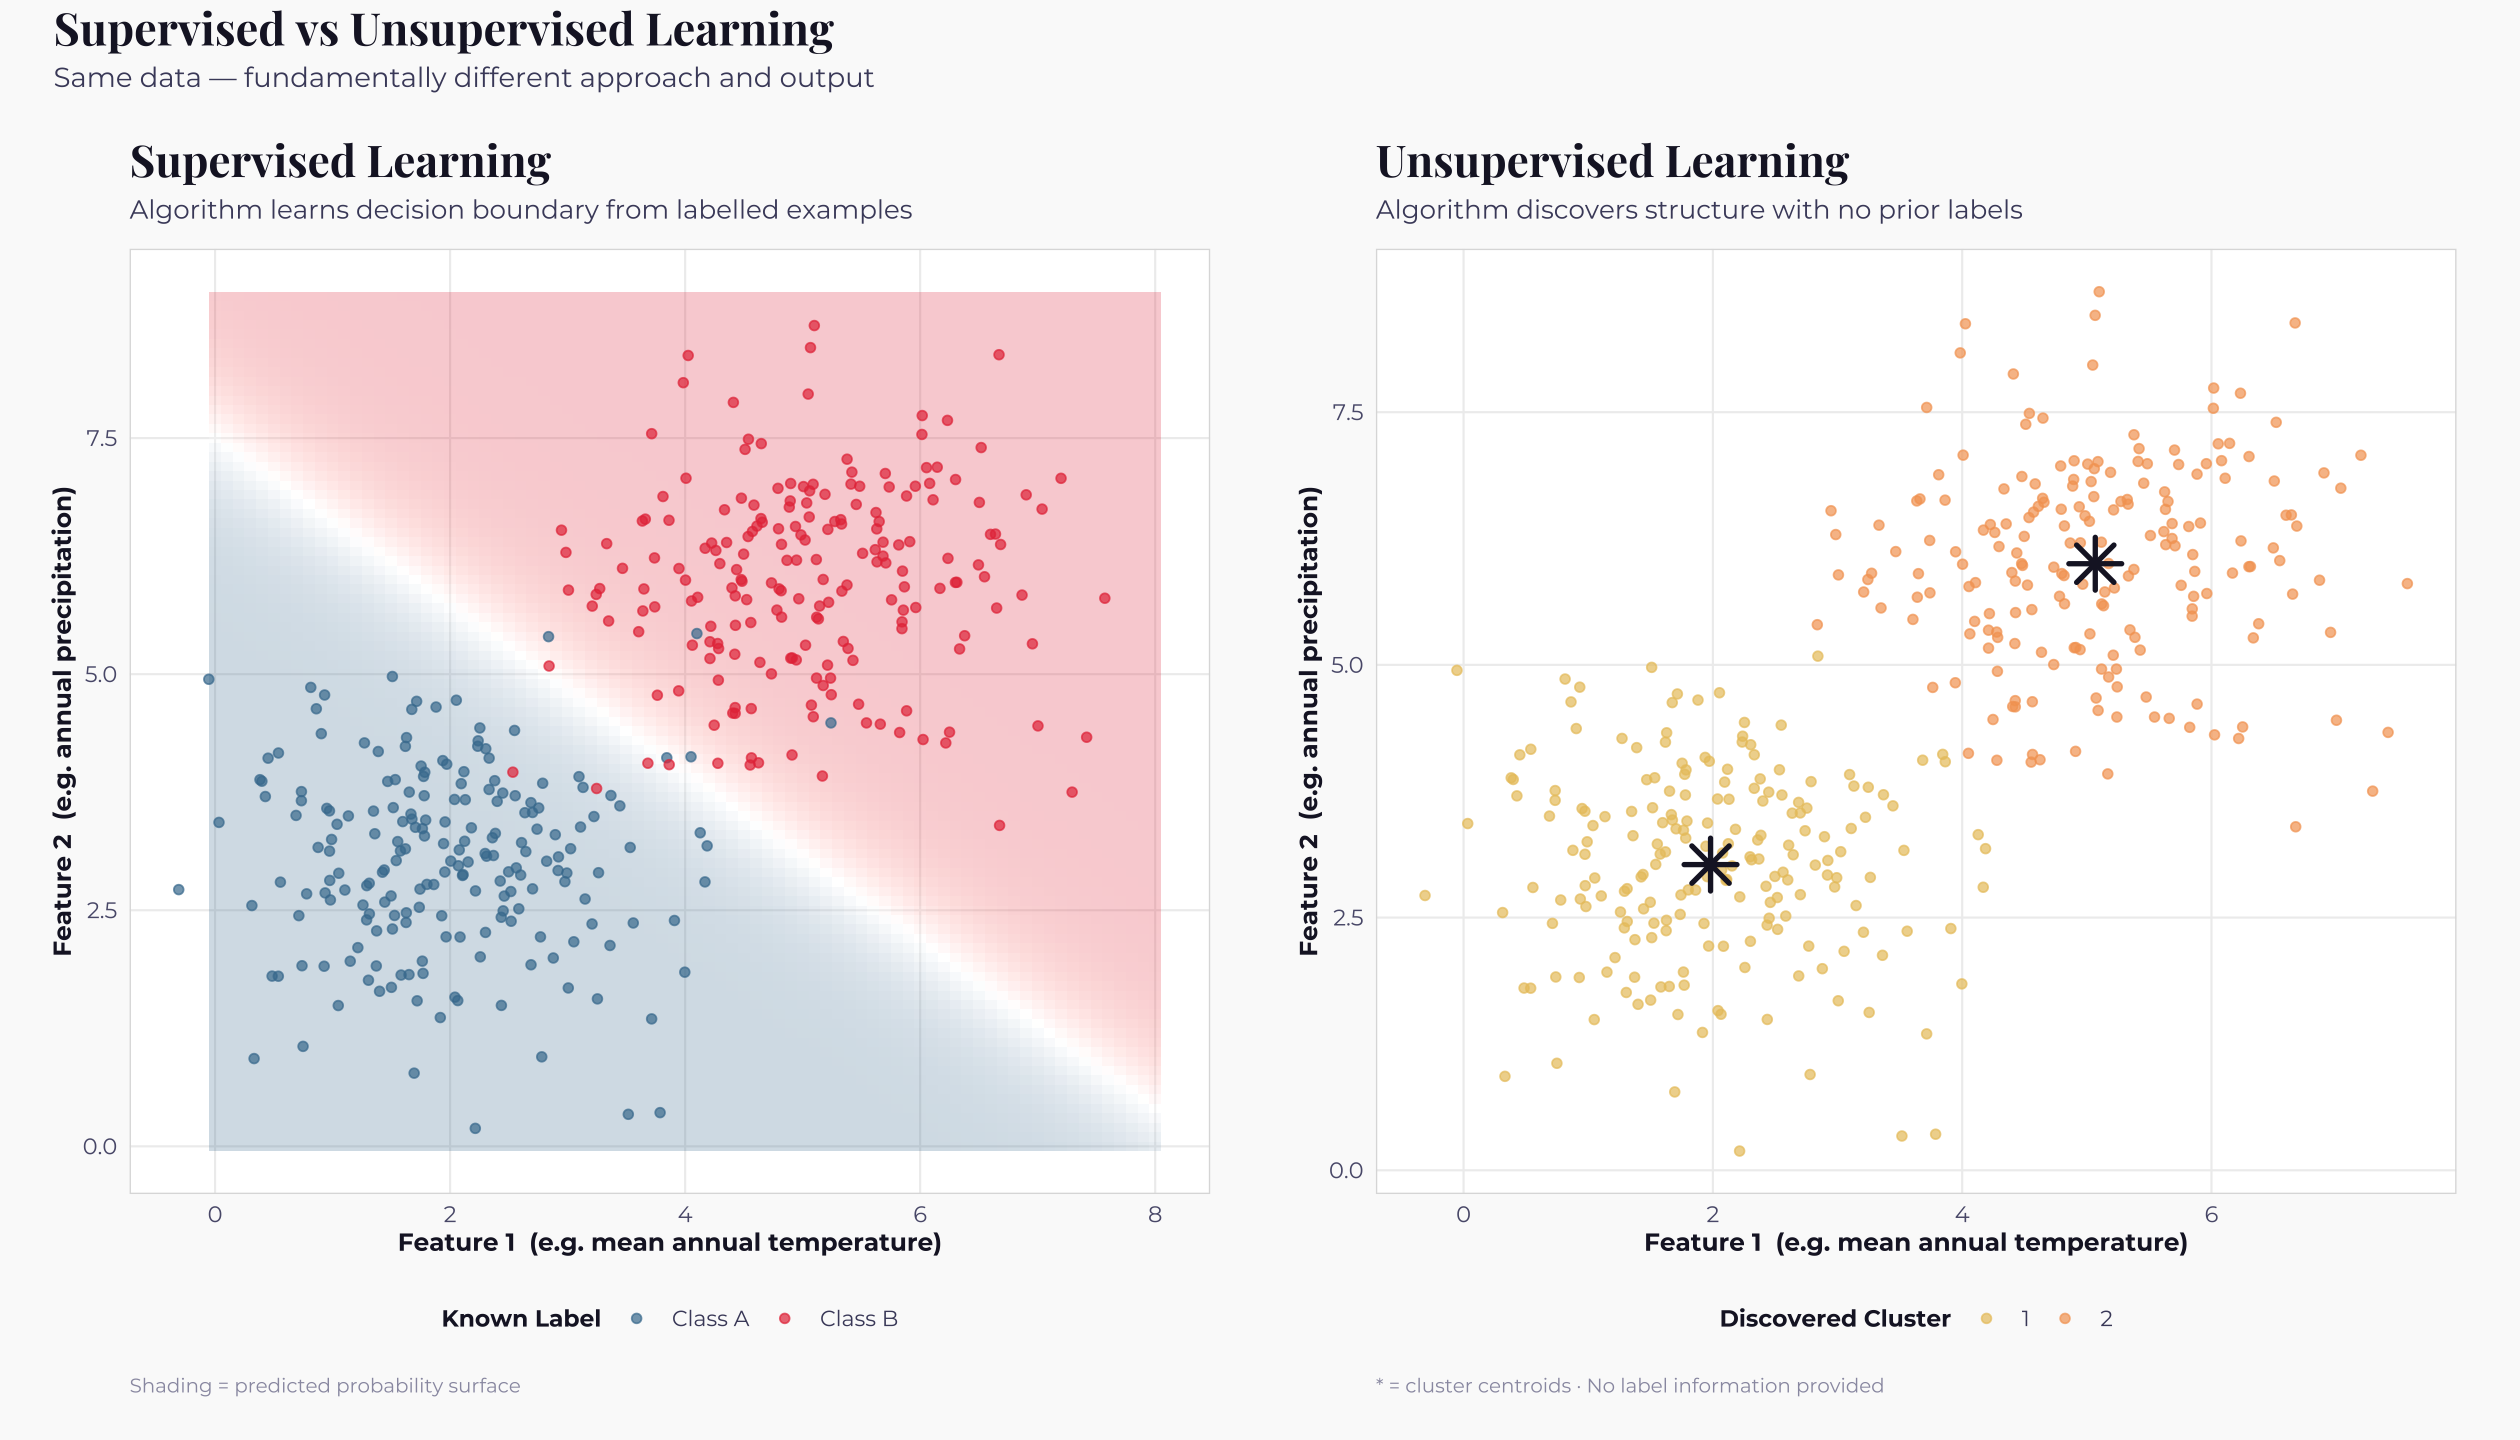


There is also a smaller third branch, **reinforcement learning**, where an *agent* learns by trial and error, receiving rewards for good actions and penalties for bad ones. It is the machinery behind [AlphaGo](https://deepmind.google/research/alphago/) and self-driving cars, and there is growing interest in using it for adaptive patrol scheduling in anti-poaching. We will not be covering it because I have not made much research on it, but you should recognise the name when you meet it in a seminar.

## The general machine-learning workflow

Whatever algorithm you eventually reach for, the scaffolding around it is almost always the same. A machine-learning project is a loop with seven stations, and although experienced practitioners may spend 90% of their time on station three, none of the seven can be skipped without consequences. The rest of this section will move through these stations repeatedly; it helps to have a mental image of the whole journey before we start the first leg.

The loop begins when you **ask a question** that is specific enough to answer with data. *"Are African penguin populations declining?"* is a research question; *"Given these measurements of colony size over the last forty years, can we forecast colony size five years from now?"* is a machine-learning question. The next step is to **collect or assemble the data** — field surveys, satellite images, sensor networks, museum records, public data portals like GBIF and Copernicus. Then comes the single most important station: **cleaning and exploring the data**. Mislabelled points, missing values, sensor drift, positional inaccuracies in GPS collars — all of these must be found and dealt with before a single model is fit. Professional machine-learning engineers often say they spend eighty percent of their time on data preparation, and they are not exaggerating.

Once the data are clean, you move to **feature engineering**, where you transform the raw measurements into inputs a model can actually learn from. Log-transforming skewed variables, creating derived indices like NDVI, turning categorical variables into dummies, handling missing values thoughtfully — this is where ecological knowledge gives you a decisive edge over someone coming in cold. You then **split the data** into a training set (for fitting the model), a validation set (for tuning it), and a test set (for honest evaluation). **Training** the model comes next; **validation** — often using cross-validation — helps you pick the best hyperparameters without peeking at the test set; and finally, one and only one time, you **evaluate on the test set**. That number is your honest estimate of how the model will behave in the real world. The loop closes with **interpretation and deployment**, which for ecologists usually means turning the model into a map, a risk score, or a recommendation for a manager.

The figure below visualises the split of data into training, validation, and test sets, together with a reminder of what each split is used for.

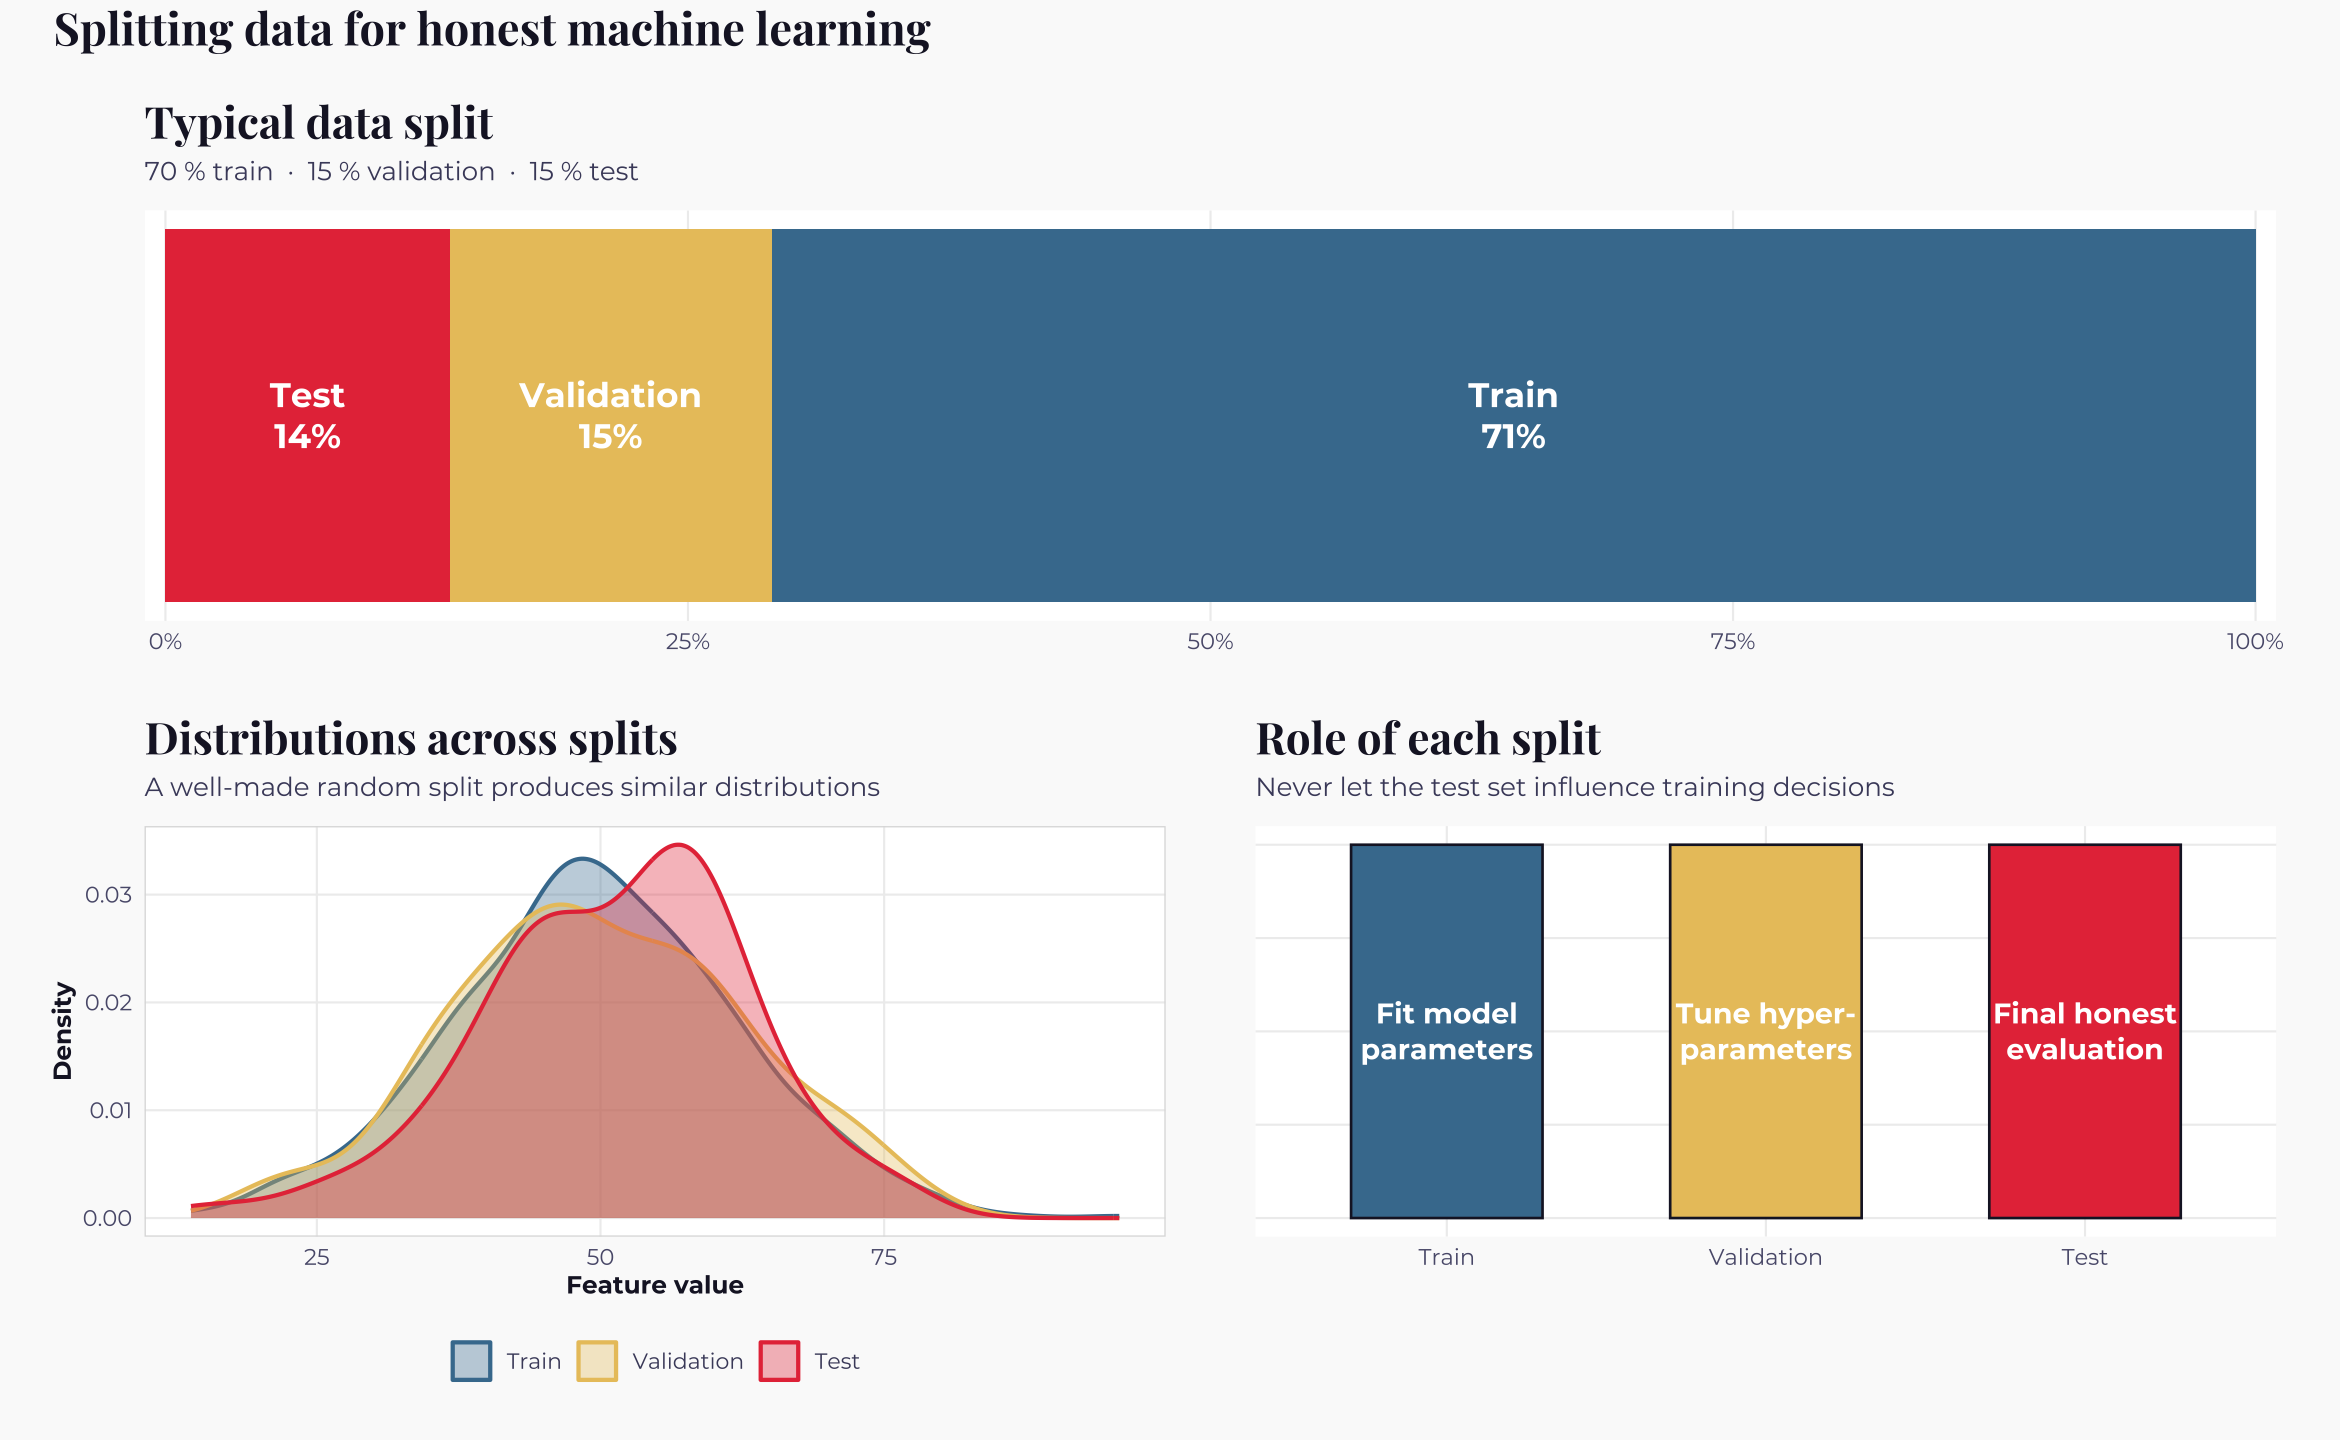

## Why data matters more than models

If there is one lesson that separates an experienced machine-learning practitioner from a beginner, it is this: the choice of algorithm matters much less than beginners expect, and the quality of the data matters much more. Peter Norvig, research director at Google, put it memorably: *"More data beats clever algorithms. Better data beats more data."* A well-prepared dataset fed to a simple model will almost always outperform a messy dataset fed to a sophisticated one, and the few exceptions to that rule tend to be found in domains (like image recognition) where someone has already done the hard data work at enormous expense.

For ecological machine learning in particular, there is a short hierarchy of things worth obsessing over, in order of importance. First is **data quality**: mislabelled training pixels, positional inaccuracies in GPS collars, sensor drift in cameras, inconsistent calling conventions between field teams — every single one of these will corrupt a downstream model in ways that no fancy algorithm can fix. Second is **representativeness**: are the samples you trained on covering the full range of conditions in which the model will be deployed? A land-cover classifier trained entirely on summer imagery will fail on winter scenes; a species-distribution model trained on occurrences from trail-accessible areas will predict poorly for roadless wilderness. Third is **class balance**: most conservation problems involve rare classes of interest — wetlands, threatened species, illegal activities — and machine-learning algorithms, left to their own devices, will learn to ignore rare classes because always guessing "common" gets most of their predictions right. Fourth, and often overlooked in spatial ecology, is **independence**: nearby pixels and neighbouring field plots are not independent observations, and a naive random train/test split can wildly inflate your accuracy estimates. Only after all of these have been handled does the choice of algorithm really start to matter, and by then the field of plausible models has usually shrunk to two or three.

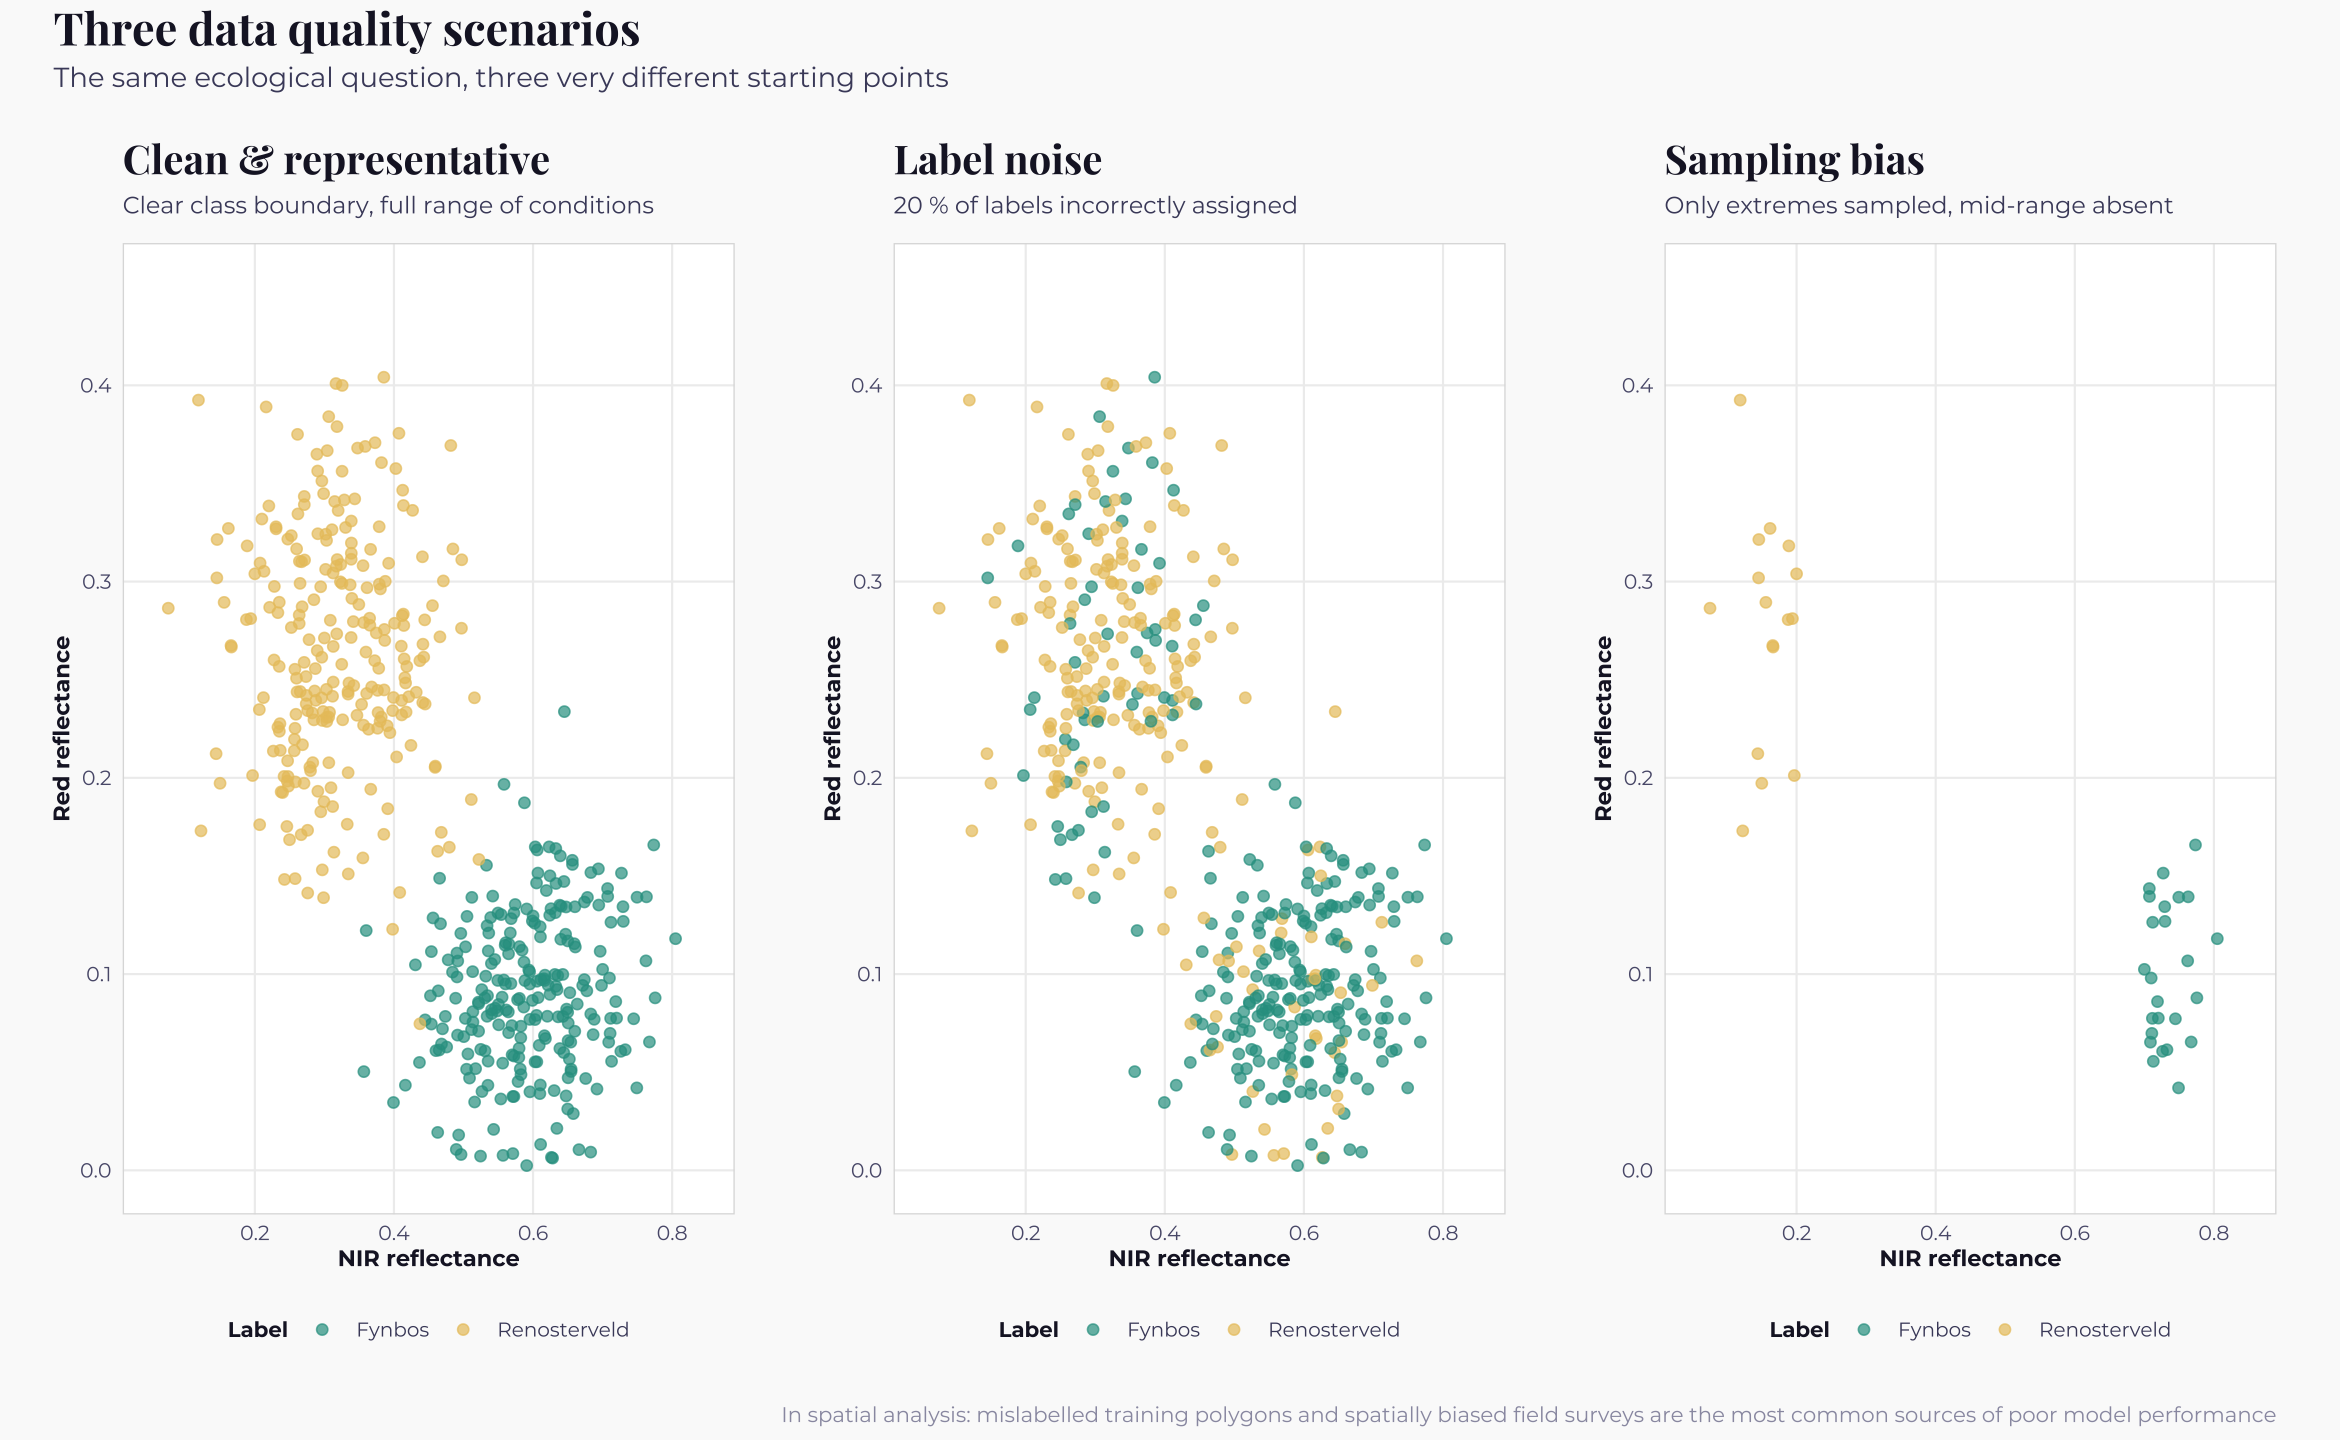

The three panels above all show a notional problem — distinguishing fynbos from renosterveld using just two spectral bands — but with data of dramatically different quality. The first panel shows what we wish every dataset looked like: a clear gap between the two classes, balanced sample sizes, and the full range of natural variability represented. The second panel shows the effect of twenty percent label noise, a plausible level of error for hand-digitised training polygons; the classes now overlap near the boundary in a way that no model, however sophisticated, can fully undo. The third panel shows sampling bias: we have only collected data from the extreme ends of the gradient, which means any model trained on this data will have no idea what to do with the messy middle that dominates the real landscape. The moral: before you pick an algorithm, look hard at your data.


## The fundamental tension — underfitting and overfitting

If you were to remember only one concept from this notebook, make it this one. Every machine-learning algorithm you will meet in this section is, in some sense, a different answer to the same question: *how flexible should my model be?* Too little flexibility and the model fails to capture the pattern that is actually there, a failure mode called **underfitting**. Too much flexibility and the model starts memorising the noise in your training data, producing predictions that look brilliant on the data it has already seen and fall apart the moment it meets anything new, a failure mode called **overfitting**. The art of machine learning is finding the sweet spot between these two extremes, and every technique for doing so — regularisation, cross-validation, early stopping, ensembling — is ultimately some version of the same dance.

An analogy that I found useful: imagine three students preparing for an ecology exam. The first has barely opened the textbook; they will fail because they have not learned enough, their mental model is too simple. The second has memorised last year's exam paper word-for-word; they will also fail, because the real exam is slightly different, and their mental model does not generalise. The third has studied the underlying principles; they will pass, because they can apply what they have learned to questions they have never seen. Underfitting is the first student, overfitting is the second, and every model we fit in this section is trying to be the third.

The figure below shows three polynomial fits to the same noisy dataset. The dashed grey line is the true underlying pattern — a smooth hump that no observer can see directly because all they have are the noisy dots. The first fit is a straight line, which is too rigid to capture the curve and so underfits. The second fit is a modest polynomial that correctly finds the hump. The third fit is a fifteenth-degree polynomial, which zigzags through every data point and looks impressive but has almost no predictive value on new data.

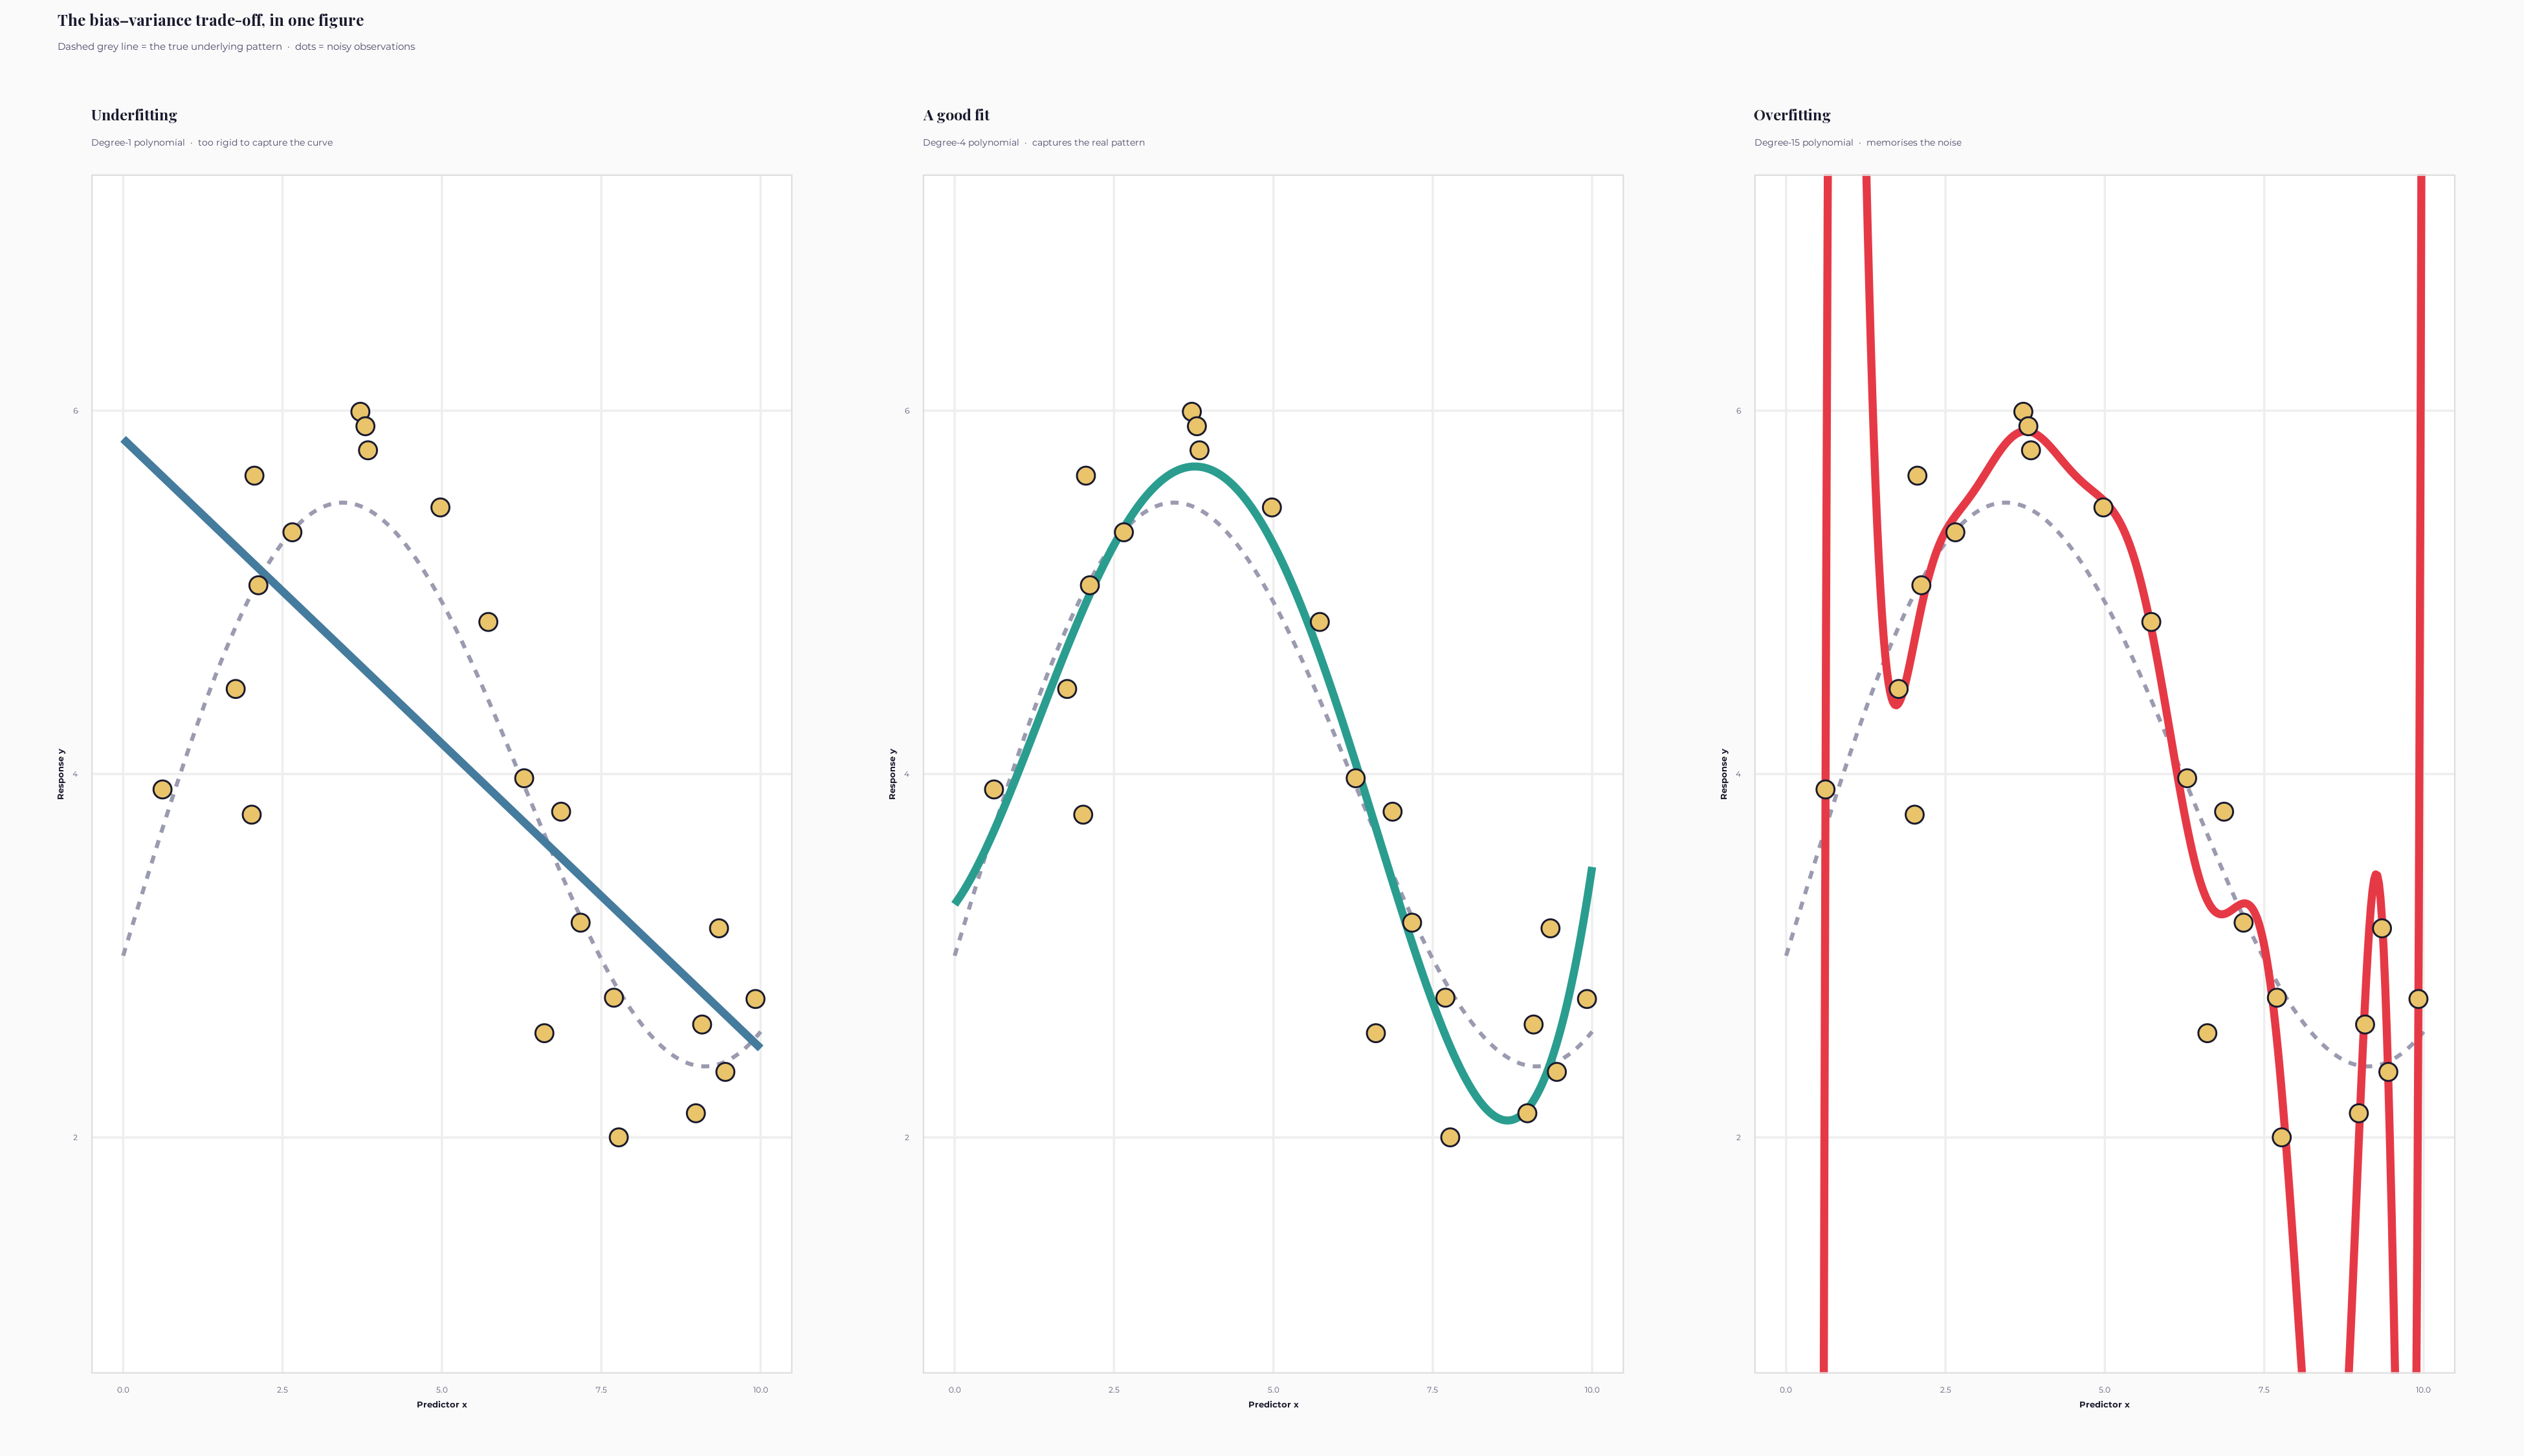

The statistical vocabulary for this trade-off is **bias** and **variance**. A model with high bias makes strong simplifying assumptions and is consistent but wrong — it underfits. A model with high variance makes very few assumptions and shifts dramatically with each new dataset — it overfits. The skill of machine learning is picking a model whose bias and variance are balanced for the problem at hand, and the standard technique for measuring that balance honestly is to hold out data the model never saw during training. We will meet cross-validation properly in Part 17 of Machine Learning, but you will see held-out evaluation in every notebook from Part 2 onwards.

## The vocabulary we will keep using

Like any field, machine learning has developed its own dialect. Here is the minimum vocabulary you will need for the rest of the Machine Learning section. You do not need to memorise these terms in one sitting; they will settle in through use, and you can return to this table whenever a word feels strange.

| Term | Plain-English meaning | Ecological analogue |
|---|---|---|
| **Observation / sample** | One row in your dataset | One pond, one pixel, one bird, one plot |
| **Feature / predictor** | One column used as input | NDVI, elevation, soil pH, temperature |
| **Label / target** | The thing the model predicts | Presence/absence, species, biomass |
| **Training set** | Data the model learns from | The 70 % of plots used to fit |
| **Validation set** | Data used to tune the model | The 15 % used to pick hyperparameters |
| **Test set** | Data used once, for honest evaluation | The final 15 %, untouched until the end |
| **Model** | The learned mapping from features to labels | *"If NDVI > 0.6 and elevation < 1500 m then 'forest'"* |
| **Parameter** | A number learned from data | A regression coefficient, a tree split |
| **Hyperparameter** | A number you set before training | Number of trees in a random forest, k in k-NN |
| **Loss / cost function** | A score of how wrong the model is | Sum of squared residuals, cross-entropy |
| **Generalisation** | Performance on new, unseen data | The whole point of modelling |



## Machine learning in ecology and conservation

Machine learning has already transformed large parts of modern conservation science, and the pace is accelerating. It is worth taking a moment to look at a few of the flagship applications, not because any single one is going to feature in your next assignment, but because they collectively illustrate how the abstract ideas of this notebook become real-world tools.

**Camera-trap image classification** may be the single most visible success story. Conservation projects now deploy tens of thousands of camera traps in networks spanning entire continents, and a single night's footage can generate more images than a human team could reasonably review in a month. Platforms like [Wildlife Insights](https://www.wildlifeinsights.org), [Wild Me](https://www.wildme.org), and [Zamba Cloud](https://www.zambacloud.com) use convolutional neural networks — deep supervised classifiers — to process this flood of imagery in near-real time, flagging species and filtering out the empty frames that make up most of the dataset. What once took a ranger three months now takes three hours, and the time saved is reinvested in the harder questions that still need human judgement.

**Bioacoustic monitoring** follows the same logic with sound instead of images. [BirdNET](https://birdnet.cornell.edu), developed by the Cornell Lab of Ornithology, can identify more than three thousand bird species from their calls using audio recorded by cheap automatic recorders left in the field for weeks at a time. Similar systems now exist for bats, frogs, cetaceans, and even insect choruses. The combination of cheap hardware and machine-learning software is quietly enabling a kind of permanent, passive biodiversity monitoring that would have been unthinkable a decade ago.

**Species distribution modelling** — predicting where species occur from environmental variables — is the area of ecology where machine learning arguably arrived earliest. MaxEnt, a maximum-entropy approach developed by Steven Phillips and colleagues in the mid-2000s, rapidly became one of the most cited tools in the field; you will meet it in Part 12. More recently, random forests, boosted trees, and deep learning have joined the toolkit, and the rise of GBIF and other open occurrence databases has given every ecologist free access to millions of training examples.

**Global land-cover mapping** has been reinvented by machine learning. The European Space Agency's WorldCover product and Google's Dynamic World product both use supervised classifiers trained on curated reference datasets to produce global maps at ten-metre resolution. A decade ago, producing a single-year global land-cover map was a multi-year, multi-million-dollar endeavour; Dynamic World now produces a new map every few days.

**Whale detection from satellite imagery**, **illegal-fishing detection** in the Global Fishing Watch system, **movement-state inference** from GPS tracks, **connectivity modelling** for corridor design, **smart patrol planning** with the PAWS system — the list goes on, and every entry is a machine-learning pipeline at its core. The common thread is this: wherever conservation has access to a lot of data and not enough human hours to process it, machine learning has found a role.


## A first hands-on glimpse — the Palmer penguins

To end Part 1 of Machine Learning, let us look at a real ecological dataset with the eyes of someone about to build a classifier. The **Palmer penguins** dataset, curated by Kristen Gorman and colleagues at the Palmer Station Long-Term Ecological Research programme in Antarctica, contains body measurements for three penguin species — *Adélie*, *Chinstrap*, and *Gentoo* — sampled across three islands. It has become the go-to teaching dataset for modern statistical ecology, and we will meet it repeatedly in this section.

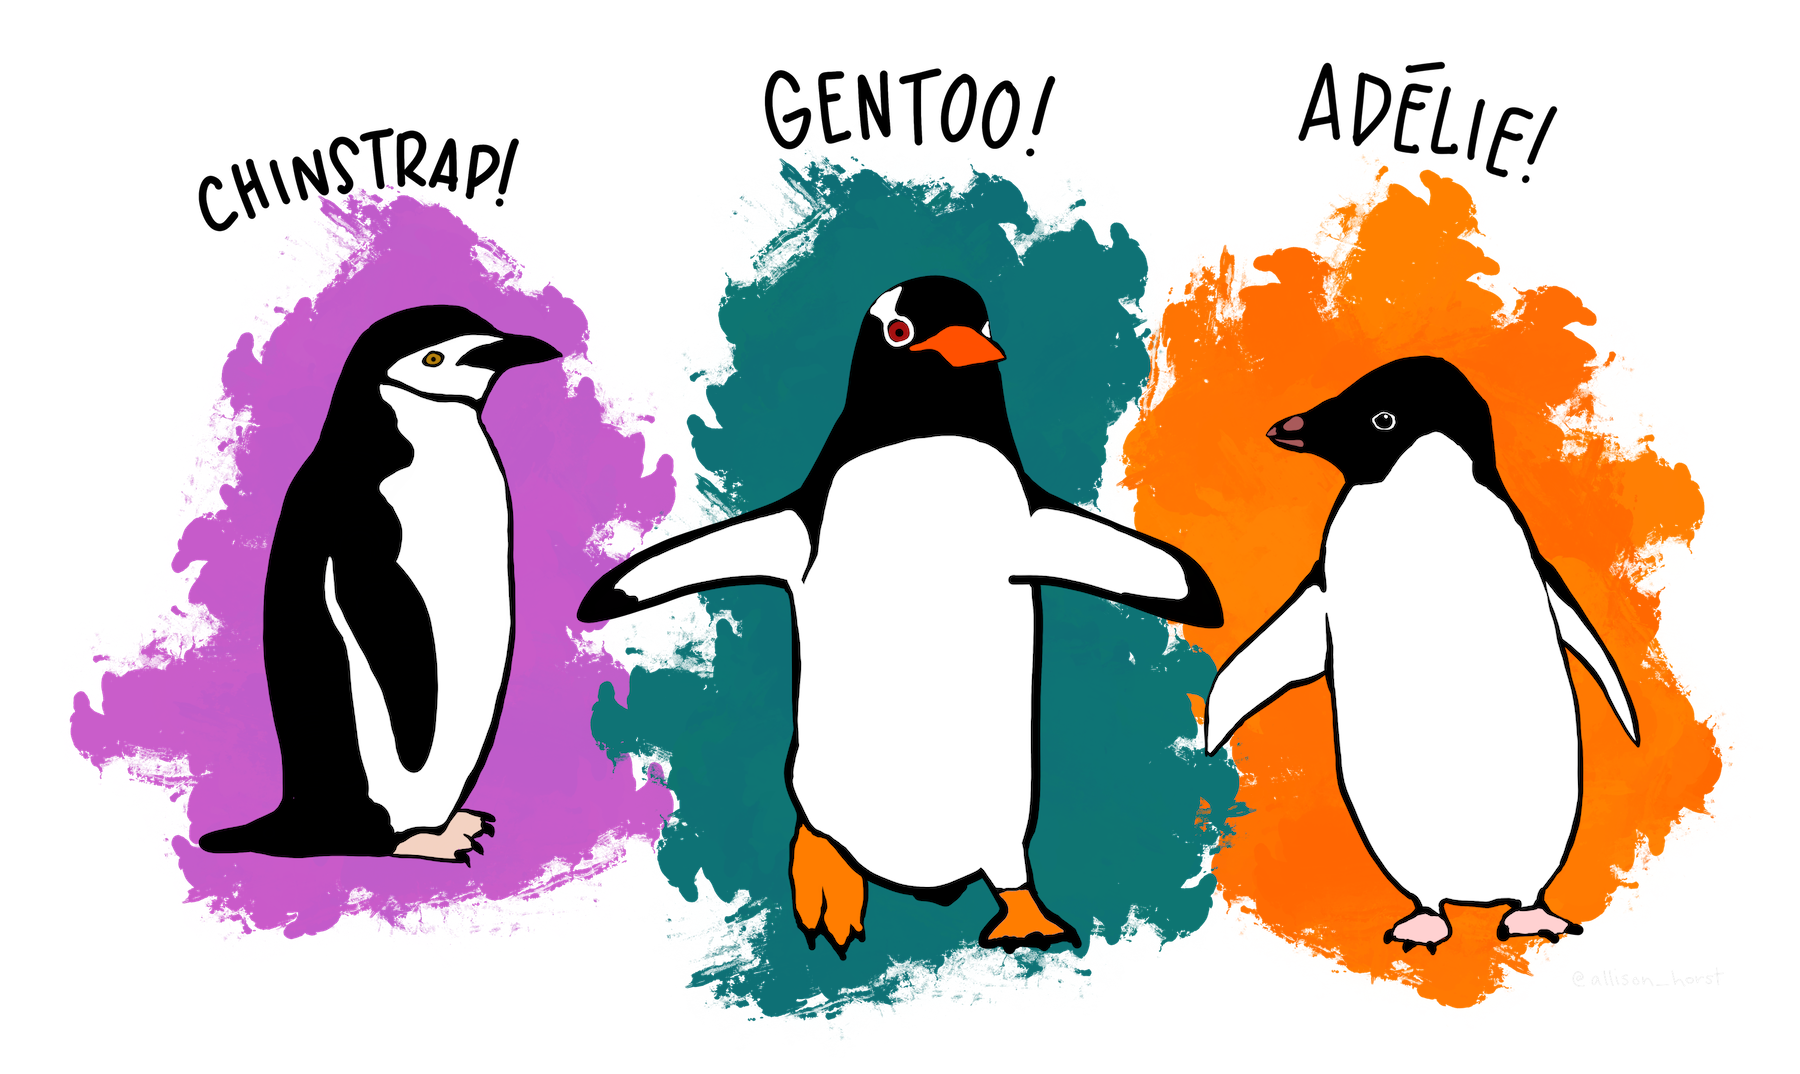
_Penguins Image by Allison Horst_

We are not going to build a model here. Instead we are going to do something more subtle but equally important: we are going to *see* the structure in the data. One of the joys of classification in ecology is that many interesting problems are already clearly separable by eye in two dimensions, which means anyone can build an intuition for what a classifier does before ever fitting one. 

### Libraries and visual theme

We begin by loading the packages we will need and defining a consistent visual theme that will be used across every notebook under Machine Learning. The theme below gives us Playfair Display for titles, Montserrat for body text, and a vibrant palette that is inspired by modern scientific publication standards.

In [1]:
# Core libraries
suppressPackageStartupMessages({
  library(tidyverse)       # data manipulation and ggplot2
  library(patchwork)       # composing multi-panel figures
  library(showtext)        # beautiful Google Fonts in ggplot
  library(ggridges)        # ridgeline plots
  library(scales)          # nicer axis formatting
  library(palmerpenguins)  # palmer penguins dataset
})

# Global plot dimensions for the notebook
options(
  repr.plot.width  = 13,
  repr.plot.height = 7.5,
  repr.plot.res    = 180
)

In [2]:
# Elegant typography
font_add_google("Playfair Display", "playfair")   # serif — titles
font_add_google("Montserrat",       "mont")       # sans  — body
font_add_google("Fira Code",        "fira")       # mono  — code
showtext_auto()

In [3]:
# The house theme — used on every figure under Machine learning.
theme_ml <- function(base_size = 11) {
  theme_minimal(base_family = "mont", base_size = base_size) +
    theme(
      plot.background   = element_rect(fill = "#fafafa", colour = NA),
      panel.background  = element_rect(fill = "#ffffff", colour = NA),
      panel.grid.major  = element_line(colour = "#eeeeee", linewidth = 0.4),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(colour = "#dddddd", fill = NA,
                                       linewidth = 0.5),
      plot.title        = element_text(family = "playfair", face = "bold",
                                       size   = base_size * 1.6,
                                       colour = "#1a1a2e",
                                       margin = margin(b = 6)),
      plot.subtitle     = element_text(size   = base_size * 0.95,
                                       colour = "#4a4a6a",
                                       margin = margin(b = 10)),
      plot.caption      = element_text(size = base_size * 0.72,
                                       colour = "#9a9ab0", hjust = 0,
                                       margin = margin(t = 10)),
      axis.title        = element_text(colour = "#1a1a2e",
                                       size = base_size * 0.9, face = "bold"),
      axis.text         = element_text(colour = "#5a5a7a",
                                       size = base_size * 0.82),
      legend.position   = "bottom",
      legend.title      = element_text(face = "bold", colour = "#1a1a2e",
                                       size = base_size * 0.85),
      legend.text       = element_text(colour = "#4a4a6a",
                                       size = base_size * 0.8),
      strip.background  = element_rect(fill = "#1a1a2e", colour = NA),
      strip.text        = element_text(colour = "white", face = "bold",
                                       size = base_size * 0.85),
      plot.margin       = margin(16, 20, 12, 16)
    )
}

# Colour palettes
PalDiscrete   <- c("#e63946", "#457b9d", "#2a9d8f", "#e9c46a",
                   "#f4a261", "#6c5ce7", "#264653", "#b5838d")
PalDiverging  <- c("#2166ac", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d")
PalSequential <- c("#fff9f0", "#fdd49e", "#fdbb84", "#fc8d59",
                   "#d7301f", "#7f0000")

In [4]:
peng <- penguins %>% 
 drop_na()

cat("Observations:", nrow(peng),
    "  |  Species represented:", paste(levels(peng$species), collapse = ", "),
    "\n")

head(peng)

Observations: 333   |  Species represented: Adelie, Chinstrap, Gentoo 


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


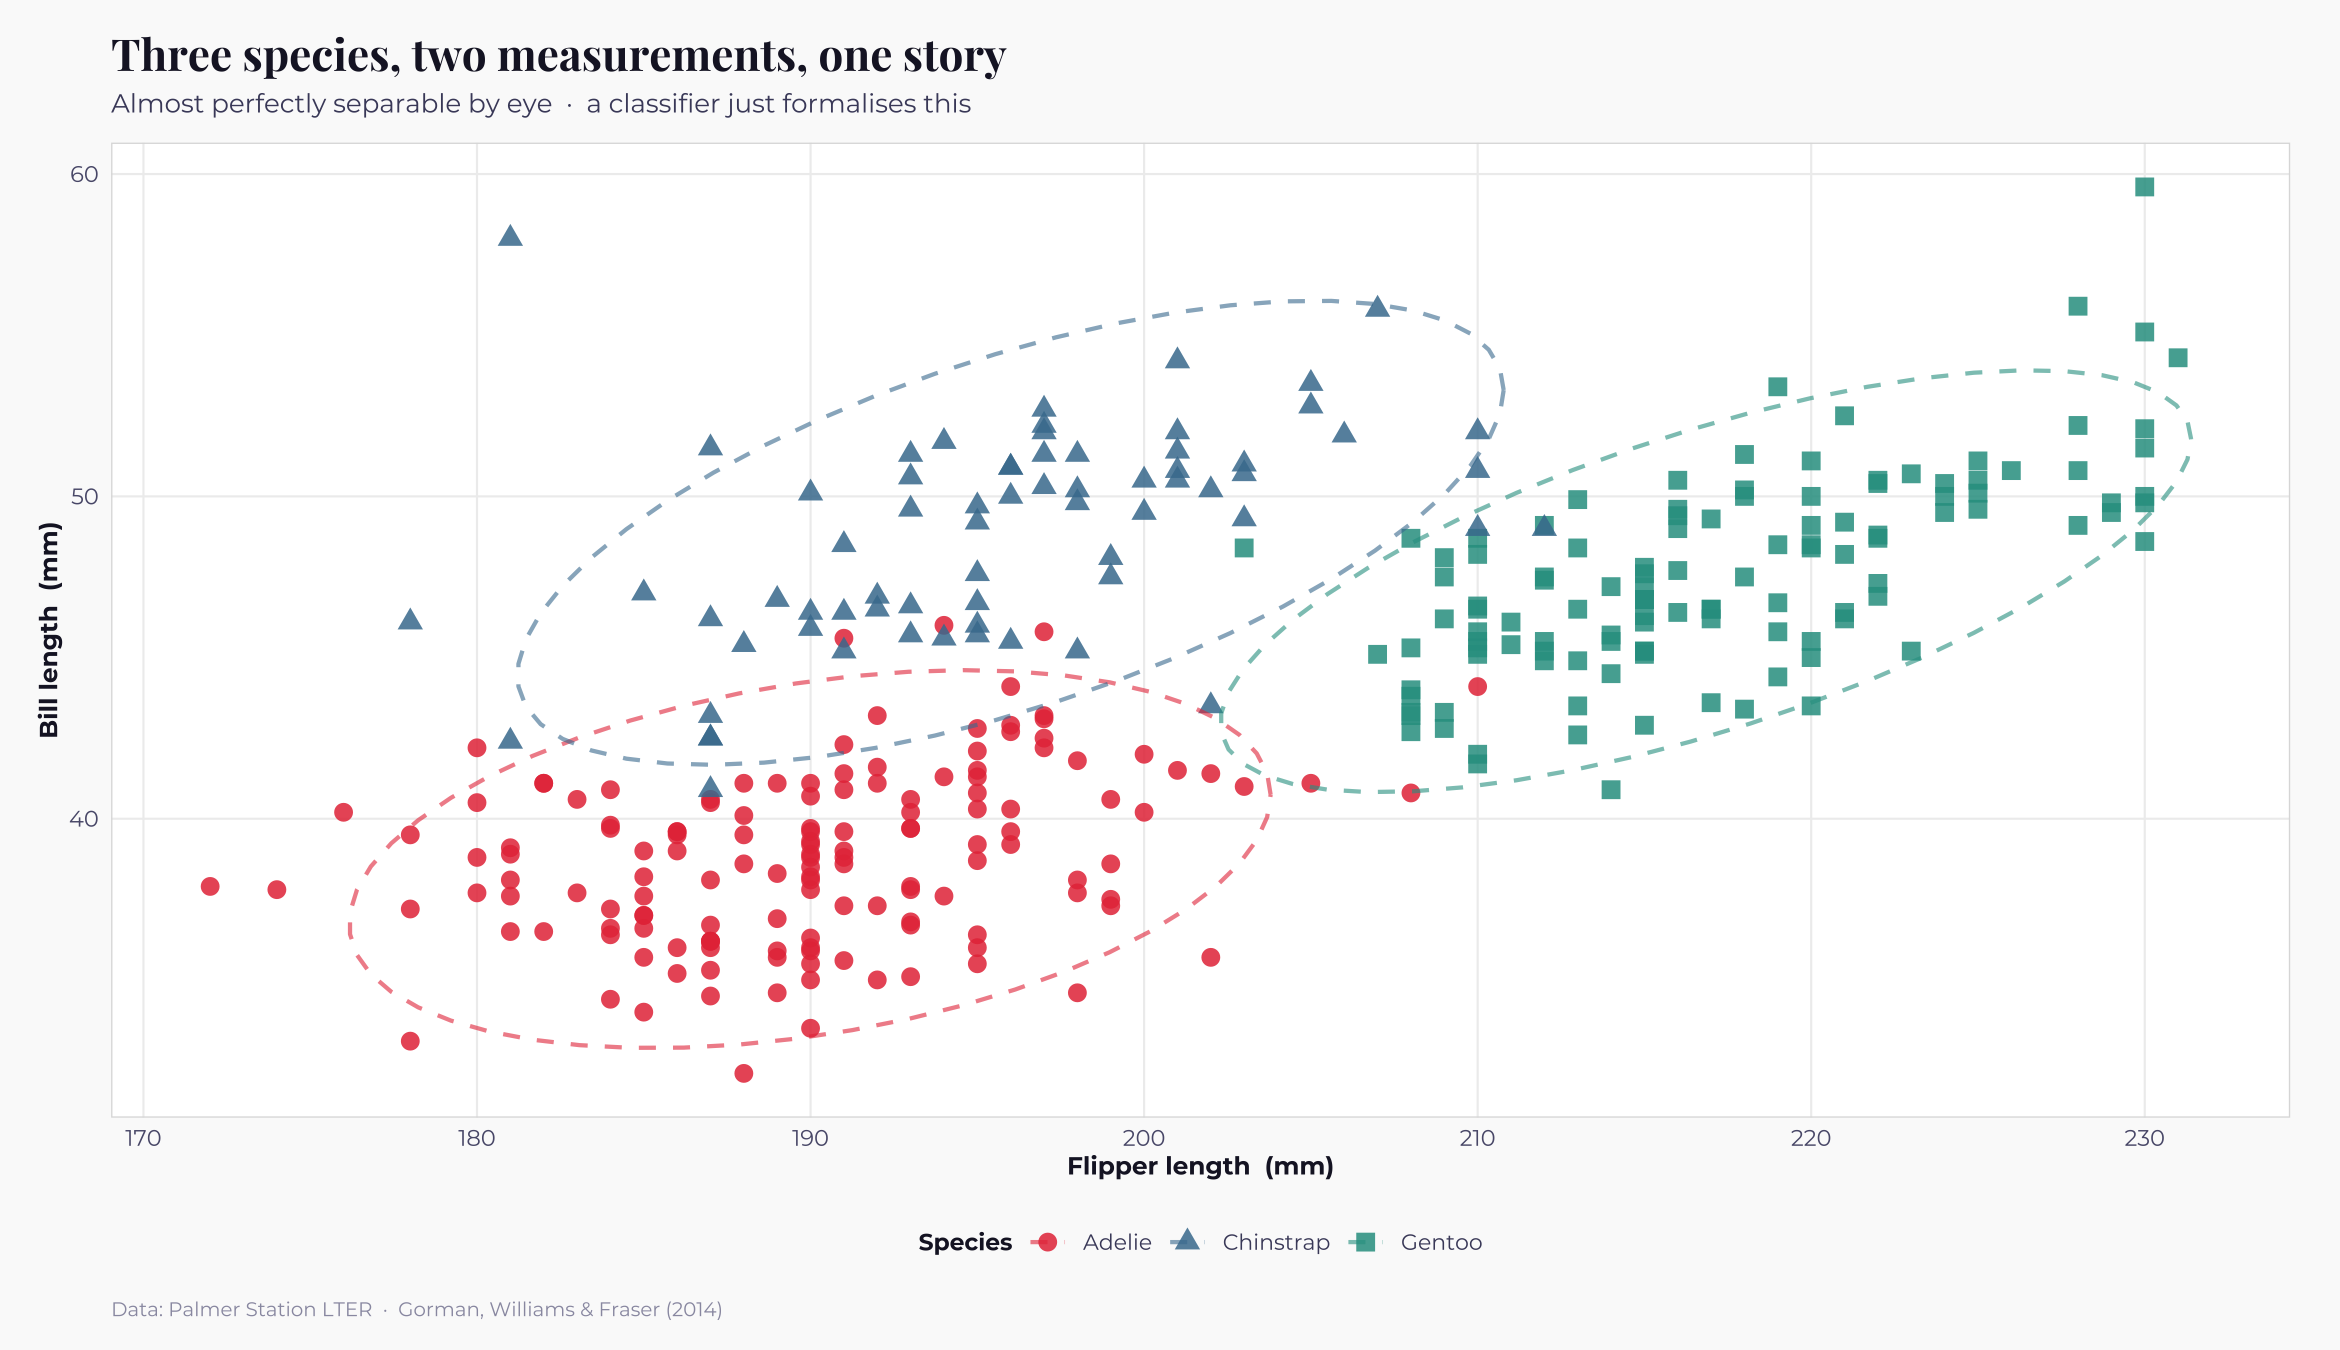

In [5]:
library(ggplot2)

ggplot(peng, aes(flipper_length_mm, bill_length_mm,
                 colour = species, shape = species)) +
  geom_point(size = 3.2, alpha = 0.85) +
  stat_ellipse(linewidth = 0.8, linetype = "dashed", alpha = 0.6) +
  scale_colour_manual(values = PalDiscrete[c(1, 2, 3)], name = "Species") +
  scale_shape_manual(values = c(16, 17, 15), name = "Species") +
  labs(title    = "Three species, two measurements, one story",
       subtitle = "Almost perfectly separable by eye  ·  a classifier just formalises this",
       x = "Flipper length  (mm)",
       y = "Bill length  (mm)",
       caption = "Data: Palmer Station LTER  ·  Gorman, Williams & Fraser (2014)") +
  theme_ml()

The figure above plots flipper length against bill length, coloured by species. Notice that the three clouds of points are almost completely distinct. A classifier is simply a formalisation of the lines your eye is already drawing between them. The ellipses are ninety-five percent confidence regions for each species, drawn under the assumption of a bivariate normal distribution. They do not perfectly capture the shape of each cloud, but they make a useful point: every classifier you will meet in this section — logistic regression, k-nearest-neighbours, random forests, support vector machines — is ultimately drawing some version of a boundary between these clouds. The differences between algorithms comes down to the assumptions they make about where the boundaries should be and how much they should wiggle. A linear classifier draws straight lines; a random forest draws staircases; a neural network draws whatever shape the data suggest. Understanding those differences is what Parts 05 through 11 are about.

It is worth looking at one more view of these data before we close. The ridgeline plot below shows the full distribution of each measurement, broken down by species. It gives a very quick answer to the question *"which of my features actually matter for telling these species apart?"* — the more separated the ridges, the more informative the feature.

Picking joint bandwidth of 0.384

Picking joint bandwidth of 1.08

Picking joint bandwidth of 153

Picking joint bandwidth of 2.4



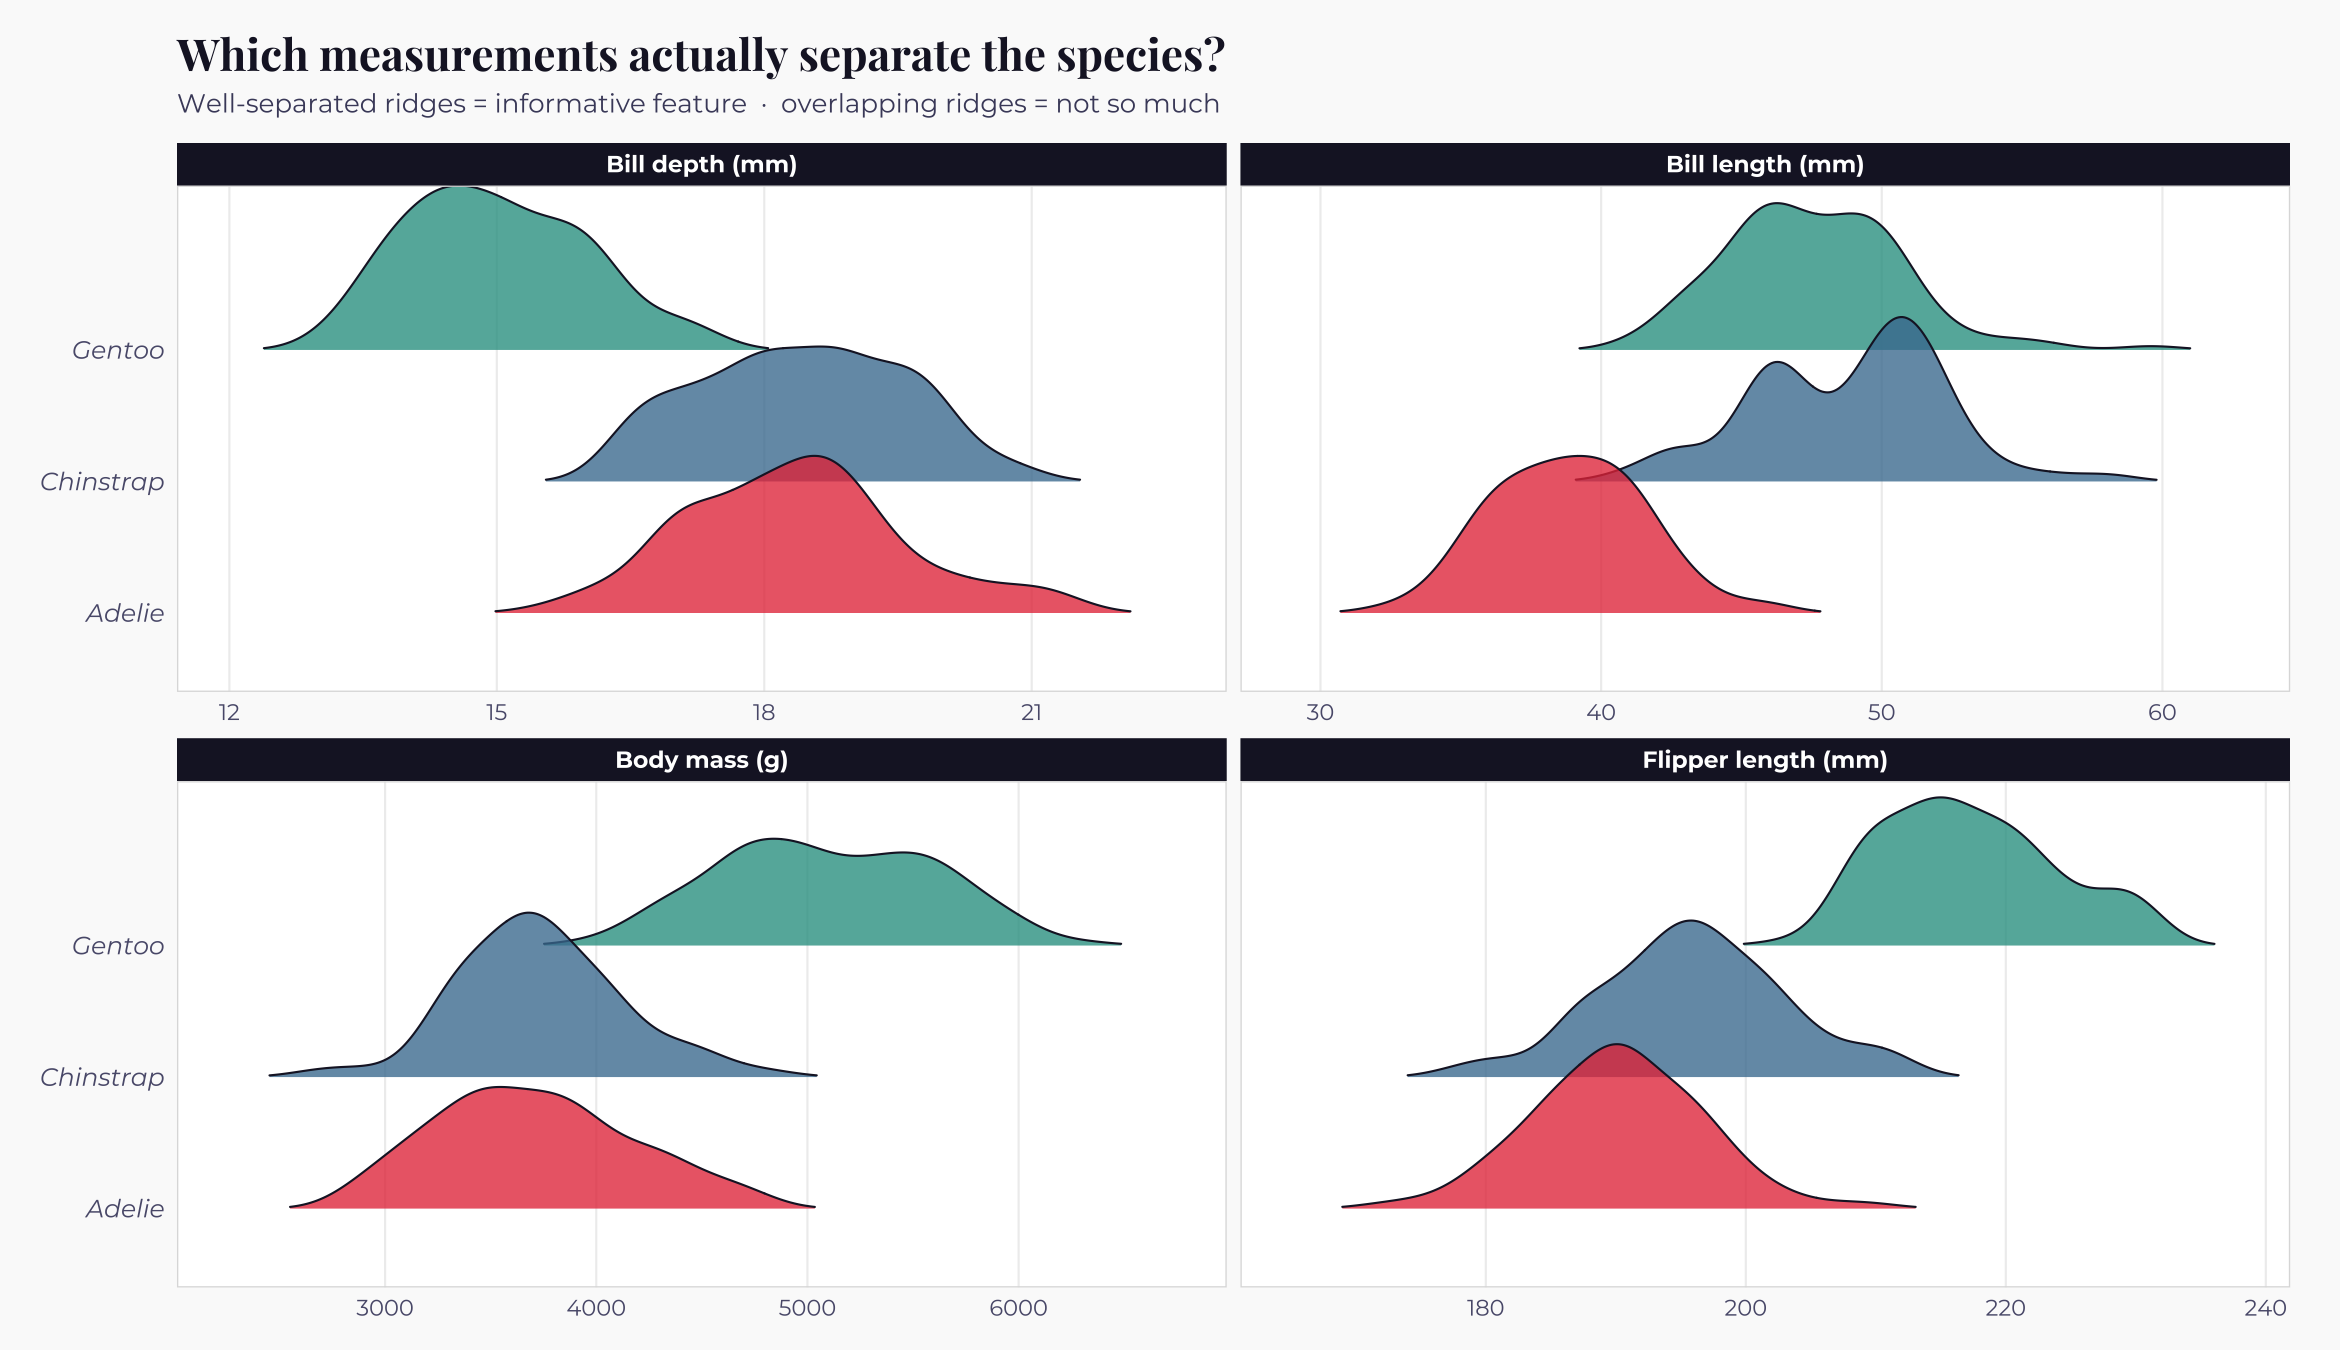

In [6]:
peng_long <- peng %>%
  select(species, bill_length_mm, bill_depth_mm,
         flipper_length_mm, body_mass_g) %>%
  pivot_longer(-species, names_to = "feature", values_to = "value") %>%
  mutate(feature = recode(feature,
    "bill_length_mm"    = "Bill length (mm)",
    "bill_depth_mm"     = "Bill depth (mm)",
    "flipper_length_mm" = "Flipper length (mm)",
    "body_mass_g"       = "Body mass (g)"
  ))

ggplot(peng_long, aes(x = value, y = species, fill = species)) +
  geom_density_ridges(alpha = 0.78, colour = "#1a1a2e",
                      linewidth = 0.4, scale = 1.25, rel_min_height = 0.01) +
  scale_fill_manual(values = PalDiscrete[c(1, 2, 3)], guide = "none") +
  facet_wrap(~ feature, scales = "free_x", ncol = 2) +
  labs(title    = "Which measurements actually separate the species?",
       subtitle = "Well-separated ridges = informative feature  ·  overlapping ridges = not so much",
       x = NULL, y = NULL) +
  theme_ml() +
  theme(axis.text.y = element_text(face = "italic", size = 10),
        panel.grid.major.y = element_blank())


The ridges tell a clear story. **Body mass** almost completely separates Gentoo penguins from the other two. **Flipper length** does nearly the same job. **Bill depth** too. **Bill length** separates Adélie from the other two. This kind of exploration, what machine-learning practitioners call *feature inspection*, is a routine part of step three in the workflow, and if you can read a figure like this at a glance, you are already thinking like a quantitative ecologist.


## Where we go from here

Introduction to Machine Learning, above all, a conceptual one. We have framed machine learning as the science of learning rules from examples, distinguished the three tasks (classification, regression, clustering) and two main paradigms (supervised and unsupervised), walked through the workflow that every project follows, and confronted the fundamental tension between underfitting and overfitting that shapes every algorithm you will meet. We have also spent time insisting, as seriously as we can, that the quality of your data matters much more than the sophistication of your model — a lesson that the field learns and then re-learns with each new generation of practitioners.

The remaining sixteen parts in this section will each introduce one algorithm and use it to answer an ecological question. Part 02 begins with the oldest tool in the supervised-learning toolbox, **linear regression** — a method that has been quietly carrying ecology on its shoulders for nearly two hundred years, and which remains one of the most useful things in your kit. From there we will generalise linear regression to the richer family of generalised linear models in part 03, meet the flexible generalised additive models of part 04, and then step into modern classifiers beginning with logistic regression in part 05.

By the end of the Machine Learning section you will have fit models that predict where species occur, classify pixels from satellite imagery, cluster animal movement behaviours, and forecast population trajectories. But all of those applications rest on the ideas we have laid down today. The machinery will get more elaborate; the principles will not change.

---

### Short exercises for reflection

Before you move to part 02, take a moment to test your intuition. These do not require any code.

1. A colleague gives you ten thousand unlabelled recordings of bat echolocation calls and asks *"how many call types are in here?"* — is this a supervised or an unsupervised problem, and why?
2. You want to predict tomorrow's stream temperature from today's air temperature, flow rate, and upstream canopy cover. Is this a regression or a classification problem?
3. Your model achieves ninety-nine percent accuracy on its training set and fifty-four percent accuracy on its held-out test set. In one word, what has gone wrong?
4. Name one ecological feature you might derive from a Sentinel-2 satellite image over a tropical forest plot. Why would that feature be useful for distinguishing forest from agriculture?
5. Why should a conservation biologist worry about biased training data when building a camera-trap classifier? Think about where cameras tend to get placed, and which species might be over- or under-represented as a result.

---

If you can answer these with confidence, you are ready for part 02. If any of them feel uncertain, the best cure is to scroll back through the relevant section of this notebook and re-read it slowly. You are not expected to have everything at your fingertips yet, this is the first of seventeen chapters, and every idea here will return.

See you in part 02, where we fit our first real model.🐧